## 1.1 — Loading SkillCorner data and matches

Clone the dataset and load matches.json to get available match IDs.

In [22]:
# Clone the dataset (run once)
!git clone https://github.com/SkillCorner/opendata.git

import json

# Load matches metadata
matches_path = "opendata/data/matches.json"

with open(matches_path, "r") as f:
    matches = json.load(f)

print("Number of matches:", len(matches))
print("\nFirst 3 matches:\n")

for match in matches[:3]:
    print(match)

fatal: destination path 'opendata' already exists and is not an empty directory.
Number of matches: 10

First 3 matches:

{'id': 2017461, 'date_time': '2025-05-17T09:35:00Z', 'home_team': {'id': 868, 'short_name': 'Melbourne V FC'}, 'away_team': {'id': 4177, 'short_name': 'Auckland FC'}, 'status': 'closed', 'competition_id': 61, 'season_id': 95, 'competition_edition_id': 870}
{'id': 2015213, 'date_time': '2025-05-03T08:00:00Z', 'home_team': {'id': 1803, 'short_name': 'Western United'}, 'away_team': {'id': 4177, 'short_name': 'Auckland FC'}, 'status': 'closed', 'competition_id': 61, 'season_id': 95, 'competition_edition_id': 870}
{'id': 2013725, 'date_time': '2025-04-27T07:00:00Z', 'home_team': {'id': 1803, 'short_name': 'Western United'}, 'away_team': {'id': 869, 'short_name': 'Sydney FC'}, 'status': 'closed', 'competition_id': 61, 'season_id': 95, 'competition_edition_id': 870}


##  1.2 — Loading dynamic events for one match

Load the dynamic events file for one match to inspect the structure and identify key variables.


In [23]:
import pandas as pd

# Select one match
match_id = matches[0]["id"]

# Define match folder path
match_folder = f"opendata/data/matches/{match_id}"

print("Match ID:", match_id)
print("Match folder:", match_folder)

# Load dynamic events file
events = pd.read_csv(f"{match_folder}/{match_id}_dynamic_events.csv")

# Inspect dataset
print("\nShape:", events.shape)
print("\nFirst 20 columns:\n", events.columns[:20].tolist())

print("\nSample rows:\n")
events.head()

Match ID: 2017461
Match folder: opendata/data/matches/2017461

Shape: (4188, 294)

First 20 columns:
 ['event_id', 'index', 'match_id', 'frame_start', 'frame_end', 'frame_physical_start', 'time_start', 'time_end', 'minute_start', 'second_start', 'duration', 'period', 'attacking_side_id', 'attacking_side', 'event_type_id', 'event_type', 'event_subtype_id', 'event_subtype', 'player_id', 'player_name']

Sample rows:



/tmp/ipykernel_11642/2057860939.py:13: DtypeWarning: Columns (75,77,184,264) have mixed types. Specify dtype option on import or set low_memory=False.
  events = pd.read_csv(f"{match_folder}/{match_id}_dynamic_events.csv")


,event_id,index,match_id,frame_start,frame_end,frame_physical_start,time_start,time_end,minute_start,second_start,...,xloss_player_possession_end,xloss_player_possession_max,xshot_player_possession_start,xshot_player_possession_end,xshot_player_possession_max,is_player_possession_start_matched,is_player_possession_end_matched,is_previous_pass_matched,is_pass_reception_matched,fully_extrapolated
0,8_0,0,2017461,2512,2512,NaN,00:00.2,00:00.2,0,0,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,True,False
1,1_0,1,2017461,2523,2539,NaN,00:01.3,00:02.9,0,1,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,NaN
2,8_1,2,2017461,2526,2540,NaN,00:01.6,00:03.0,0,1,...,NaN,NaN,NaN,NaN,NaN,True,True,True,True,False
3,7_0,3,2017461,2526,2528,NaN,00:01.6,00:01.8,0,1,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,False
4,7_1,4,2017461,2526,2540,NaN,00:01.6,00:03.0,0,1,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,False


##  1.3 — Isolating off-ball runs

Filter the full events table to keep only off-ball runs, then inspect their count and subtype distribution.


In [24]:
# Reload with low_memory=False to reduce mixed-type warnings
events = pd.read_csv(f"{match_folder}/{match_id}_dynamic_events.csv", low_memory=False)

# Keep only off-ball runs
runs = events[events["event_type"] == "off_ball_run"].copy()

# Basic inspection
print("Off-ball runs shape:", runs.shape)
print("\nRun subtypes:\n")
print(runs["event_subtype"].value_counts())

print("\nSample off-ball runs:\n")
runs[[
    "player_name",
    "event_subtype",
    "team_in_possession_phase_type",
    "team_out_of_possession_phase_type",
    "xthreat",
    "lead_to_shot",
    "lead_to_goal"
]].head(10)

Off-ball runs shape: (460, 294)

Run subtypes:

event_subtype
run_ahead_of_the_ball    134
support                   82
coming_short              52
cross_receiver            46
dropping_off              45
behind                    28
pulling_wide              27
overlap                   21
pulling_half_space        13
underlap                  12
Name: count, dtype: int64

Sample off-ball runs:



,player_name,event_subtype,team_in_possession_phase_type,team_out_of_possession_phase_type,xthreat,lead_to_shot,lead_to_goal
1,Z. Machach,run_ahead_of_the_ball,direct,defending_direct,0.0072,False,False
6,J. Valadon,coming_short,direct,defending_direct,0.0005,False,False
9,N. Velupillay,run_ahead_of_the_ball,direct,defending_direct,0.0040,False,False
19,Z. Machach,support,finish,low_block,0.0519,False,False
20,D. Arzani,cross_receiver,finish,low_block,0.0403,False,False
21,N. Vergos,cross_receiver,finish,low_block,0.1566,False,False
73,Z. Machach,run_ahead_of_the_ball,chaotic,chaotic,0.0231,False,False
74,K. Bos,support,chaotic,chaotic,0.0077,False,False
80,N. Velupillay,run_ahead_of_the_ball,chaotic,chaotic,0.0206,False,False
88,M. Francois,run_ahead_of_the_ball,transition,defending_transition,0.0070,False,False


## 1.4 — Inspecting key variables for the project

Check that the core variables (context, value, outcome, sequence) are complete and usable.

In [25]:
# Select key variables for the project
key_columns = [
    "event_subtype",
    "team_in_possession_phase_type",
    "xthreat",
    "lead_to_shot",
    "lead_to_goal",
    "index",
    "frame_start",
    "time_start"
]

runs[key_columns].info()

print("\nMissing values (%):\n")
print(runs[key_columns].isnull().mean() * 100)

<class 'pandas.core.frame.DataFrame'>
Index: 460 entries, 1 to 4163
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   event_subtype                  460 non-null    object 
 1   team_in_possession_phase_type  460 non-null    object 
 2   xthreat                        460 non-null    float64
 3   lead_to_shot                   460 non-null    bool   
 4   lead_to_goal                   460 non-null    bool   
 5   index                          460 non-null    int64  
 6   frame_start                    460 non-null    int64  
 7   time_start                     460 non-null    object 
dtypes: bool(2), float64(1), int64(2), object(3)
memory usage: 26.1+ KB

Missing values (%):

event_subtype                    0.0
team_in_possession_phase_type    0.0
xthreat                          0.0
lead_to_shot                     0.0
lead_to_goal                     0.0
index                

## Explanation of output

This step confirms that the key variables required for the analysis are fully complete and usable.

All core fields — run subtype, phase of play, xThreat, shot outcome, and sequence-related variables — have no missing values in this sample. This indicates that the dataset is well-structured at run level, with context, value, and outcome already attached to each off-ball movement.

This is an important validation step, as it means the analysis can focus directly on interpreting behaviour rather than reconstructing sequences or cleaning incomplete data.

Overall, the dataset provides a reliable foundation for analysing how off-ball runs behave across different contexts.

## 1.5 Focusing on transition and quick break runs

In [26]:
# Filter transition contexts
transition_runs = runs[
    runs["team_in_possession_phase_type"].isin(["transition", "quick_break"])
].copy()

# Inspect results
print("Transition runs shape:", transition_runs.shape)

print("\nPhase distribution:\n")
print(transition_runs["team_in_possession_phase_type"].value_counts())

print("\nSample transition runs:\n")
transition_runs[[
    "player_name",
    "event_subtype",
    "team_in_possession_phase_type",
    "xthreat",
    "lead_to_shot"
]].head(10)

Transition runs shape: (64, 294)

Phase distribution:

team_in_possession_phase_type
transition     56
quick_break     8
Name: count, dtype: int64

Sample transition runs:



,player_name,event_subtype,team_in_possession_phase_type,xthreat,lead_to_shot
88,M. Francois,run_ahead_of_the_ball,transition,0.0070,False
89,J. Randall,behind,transition,0.0263,False
96,F. De Vries,underlap,transition,0.0134,False
100,J. Randall,run_ahead_of_the_ball,transition,0.0066,False
102,G. May,cross_receiver,transition,0.0799,False
103,F. De Vries,cross_receiver,transition,0.1168,False
104,M. Francois,support,transition,0.0262,False
548,M. Francois,run_ahead_of_the_ball,transition,0.0027,False
550,G. May,run_ahead_of_the_ball,transition,0.0026,False
555,M. Francois,run_ahead_of_the_ball,transition,0.0052,False


## Understanding why the analysis focuses on transitions

Filtering the dataset to transition and quick break phases reduces the number of runs from 460 to 64 in this match. While this is a significant drop in volume, it is expected, as these phases represent specific and less frequent moments in the game.

Importantly, the filtered sample still contains a good range of run types, including support runs, runs in behind, and cross-receiver movements. This means the analysis retains behavioural diversity while focusing on a more targeted game situation.

The key decision here is whether to include additional phases, such as build-up or create phases, in order to increase the sample size.

From a data perspective, including more phases would provide more observations. However, it would also introduce a mismatch between the context of the actions and the way value is measured.

In this project, run value is captured using xThreat, which reflects the immediate attacking potential of an action within a short time window. This makes it well suited to fast attacking moments, where the impact of movement is realised quickly.

Transition and quick break phases naturally align with this structure. These are situations where teams regain possession and attempt to exploit space before the opposition reorganises. As a result, the connection between off-ball movement and attacking outcome is more direct and occurs within the same short sequence.

In contrast, runs in build-up or more structured possession phases often contribute to attacks over longer sequences. Their value may only become apparent well beyond the time window captured by xThreat, which can lead to an underestimation of their true contribution.

For this reason, the analysis focuses on transition and quick break phases. This is a deliberate methodological choice to ensure that the context of the actions and the definition of value are aligned.

The aim is not to describe all types of movement, but to isolate the situations where movement, timing, and outcome are most closely linked.

## 1.6 — Comparing run types inside transitions

Analyse how different run types behave within the same context (transitions).

In [27]:
# Compare average xThreat by run type (only in transitions)
run_value = (
    transition_runs
    .groupby("event_subtype")["xthreat"]
    .mean()
    .sort_values(ascending=False)
)

print("Average xThreat per run type (transitions):\n")
print(run_value)

# Optional: also check how often each run type occurs
run_counts = transition_runs["event_subtype"].value_counts()

print("\nRun frequency (transitions):\n")
print(run_counts)

Average xThreat per run type (transitions):

event_subtype
cross_receiver           0.147381
behind                   0.043925
support                  0.022947
overlap                  0.018100
underlap                 0.013400
run_ahead_of_the_ball    0.012732
coming_short             0.000800
Name: xthreat, dtype: float64

Run frequency (transitions):

event_subtype
run_ahead_of_the_ball    22
cross_receiver           16
support                  15
behind                    8
underlap                  1
coming_short              1
overlap                   1
Name: count, dtype: int64


#### Visual — Run Value by Type in Transitions

Average xThreat per run type (transitions):

event_subtype
coming_short             0.000800
run_ahead_of_the_ball    0.012732
underlap                 0.013400
overlap                  0.018100
support                  0.022947
behind                   0.043925
cross_receiver           0.147381
Name: xthreat, dtype: float64

Run frequency (transitions):

event_subtype
run_ahead_of_the_ball    22
cross_receiver           16
support                  15
behind                    8
underlap                  1
coming_short              1
overlap                   1
Name: count, dtype: int64


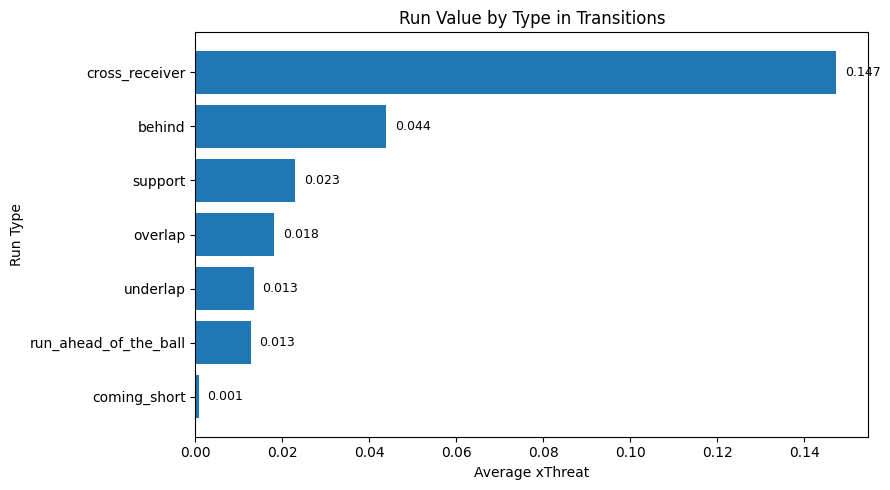

In [28]:
import matplotlib.pyplot as plt

# Compare average xThreat by run type (only in transitions)
run_value = (
    transition_runs
    .groupby("event_subtype", observed=True)["xthreat"]
    .mean()
    .sort_values(ascending=True)
)

print("Average xThreat per run type (transitions):\n")
print(run_value)

# Optional: also check how often each run type occurs
run_counts = transition_runs["event_subtype"].value_counts()

print("\nRun frequency (transitions):\n")
print(run_counts)

# --- Visual: Horizontal bar chart ---
plt.figure(figsize=(9, 5))
bars = plt.barh(run_value.index, run_value.values)

plt.xlabel("Average xThreat")
plt.ylabel("Run Type")
plt.title("Run Value by Type in Transitions")

# Add values at the end of bars
for i, v in enumerate(run_value.values):
    plt.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## Explanation of output

Within transition situations, clear differences emerge between run types.

Cross-receiver runs generate the highest attacking threat, followed by runs in behind, while support runs sit in a middle range. At the same time, more frequent movements, such as running ahead of the ball, tend to produce lower value on average.

This suggests that even within the same context, not all runs contribute equally. There is still a trade-off between frequency and impact, with higher-value actions being more selective.

At this stage, the results are based on a single match and serve as an initial indication rather than a final conclusion.

## 1.7 — Separating transition and quick break contexts

Up to this point, transition and quick break phases have been analysed together as a single context.

However, these situations may differ in speed and level of organisation.

Separating them allows us to check whether run value changes depending on how quickly the attack develops.


In [29]:
# Separate contexts
transition_only = transition_runs[
    transition_runs["team_in_possession_phase_type"] == "transition"
]

quick_break_only = transition_runs[
    transition_runs["team_in_possession_phase_type"] == "quick_break"
]

# --- TRANSITION ---
print("=== TRANSITION ===\n")

transition_values = (
    transition_only
    .groupby("event_subtype")["xthreat"]
    .mean()
    .sort_values(ascending=False)
)

print(transition_values)

print("\nRun counts (transition):\n")
print(transition_only["event_subtype"].value_counts())


# --- QUICK BREAK ---
print("\n\n=== QUICK BREAK ===\n")

quick_break_values = (
    quick_break_only
    .groupby("event_subtype")["xthreat"]
    .mean()
    .sort_values(ascending=False)
)

print(quick_break_values)

print("\nRun counts (quick break):\n")
print(quick_break_only["event_subtype"].value_counts())

=== TRANSITION ===

event_subtype
cross_receiver           0.129738
behind                   0.043925
support                  0.022145
overlap                  0.018100
underlap                 0.013400
run_ahead_of_the_ball    0.013081
coming_short             0.000800
Name: xthreat, dtype: float64

Run counts (transition):

event_subtype
run_ahead_of_the_ball    21
cross_receiver           13
support                  11
behind                    8
underlap                  1
coming_short              1
overlap                   1
Name: count, dtype: int64


=== QUICK BREAK ===

event_subtype
cross_receiver           0.223833
support                  0.025150
run_ahead_of_the_ball    0.005400
Name: xthreat, dtype: float64

Run counts (quick break):

event_subtype
support                  4
cross_receiver           3
run_ahead_of_the_ball    1
Name: count, dtype: int64


## 1.8 — Adding sequence timing

So far, the analysis has focused on run type and context. The next step is to introduce a simple sequence layer by looking at when runs occur within a transition.

Not all runs in a transition play the same role. Some happen immediately after the regain, while others occur later as the attack develops.

By grouping runs based on their timing within the sequence, we can explore whether earlier or later movements have different levels of impact.

In [30]:
# Create a simple timing variable based on event order
# We use the 'index' as a proxy for sequence position

# Normalize index within each possession-like sequence (simple approach)
transition_runs = transition_runs.sort_values("index")

# Create bins for timing (early / mid / late)
transition_runs["timing_bin"] = pd.qcut(
    transition_runs["index"],
    q=3,
    labels=["early", "middle", "late"]
)

# Check distribution
print("Timing distribution:\n")
print(transition_runs["timing_bin"].value_counts())

# Compare value by timing
timing_value = (
    transition_runs
    .groupby("timing_bin", observed=True)["xthreat"]
    .mean()
)

print("\nAverage xThreat by timing:\n")
print(timing_value)

Timing distribution:

timing_bin
early     22
middle    21
late      21
Name: count, dtype: int64

Average xThreat by timing:

timing_bin
early     0.043750
middle    0.052890
late      0.061567
Name: xthreat, dtype: float64


## 1.9 — Defining transition sequences

So far, runs have been analysed as individual actions within a filtered context. The next step is to group them into sequences, based on when each transition starts and ends.

A transition sequence begins when a team enters a transition or quick break phase, and continues until that phase ends. By identifying these sequences, we can group runs that belong to the same attacking moment.

This allows us to analyse not just isolated actions, but how movement unfolds within each transition, and to understand the role of runs at different points in the sequence.

In [31]:
# Sort by match time
transition_runs = transition_runs.sort_values("frame_start")

# Create a new sequence ID
# A new sequence starts every time the phase changes OR there is a large gap in frames

transition_runs["new_sequence"] = (
    (transition_runs["team_in_possession_phase_type"] != transition_runs["team_in_possession_phase_type"].shift())
    | (transition_runs["frame_start"] - transition_runs["frame_start"].shift() > 50)
)

# Assign sequence IDs
transition_runs["sequence_id"] = transition_runs["new_sequence"].cumsum()

# Check sequences
print("Number of sequences:", transition_runs["sequence_id"].nunique())

print("\nSample sequences:\n")
transition_runs[[
    "sequence_id",
    "player_name",
    "event_subtype",
    "frame_start",
    "team_in_possession_phase_type"
]].head(15)

Number of sequences: 19

Sample sequences:



,sequence_id,player_name,event_subtype,frame_start,team_in_possession_phase_type
88,1,M. Francois,run_ahead_of_the_ball,3280,transition
89,1,J. Randall,behind,3283,transition
96,1,F. De Vries,underlap,3323,transition
100,1,J. Randall,run_ahead_of_the_ball,3362,transition
102,1,G. May,cross_receiver,3379,transition
103,1,F. De Vries,cross_receiver,3379,transition
104,1,M. Francois,support,3379,transition
548,2,M. Francois,run_ahead_of_the_ball,7459,transition
550,2,G. May,run_ahead_of_the_ball,7462,transition
555,2,M. Francois,run_ahead_of_the_ball,7502,transition


## Explanation of output

The runs have now been grouped into transition sequences.

In this match, the 64 transition runs are split into 19 different sequences. This means that instead of looking at runs one by one, we are now looking at groups of runs that happen within the same attacking moment after a regain.

The sample shows that runs with the same sequence_id happen very close in time and involve different players and run types. This confirms that the grouping is working as expected.

This step is important because it allows us to analyse how runs behave within each transition, rather than across the whole match.

## 1.10 — Assigning timing within each transition sequence

After defining transition sequences, the next step is to position each run within its sequence.

Runs are ordered inside each transition and divided into early, middle, and late stages based on their relative position. This allows timing to reflect how the attack develops rather than when it happens in the match.

To ensure consistency, only sequences with at least 3 actions are included, so that timing categories represent meaningful stages of the attack.

In [32]:
# --- 1. Filter sequences with at least 3 actions ---
sequence_counts = transition_runs["sequence_id"].value_counts()

valid_sequences = sequence_counts[sequence_counts >= 3].index

filtered_runs = transition_runs[
    transition_runs["sequence_id"].isin(valid_sequences)
].copy()

print("Number of runs after filtering:", filtered_runs.shape[0])
print("Number of sequences kept:", filtered_runs["sequence_id"].nunique())


# --- 2. Assign order within each sequence ---
filtered_runs = filtered_runs.sort_values(["sequence_id", "frame_start"])

filtered_runs["order_in_sequence"] = (
    filtered_runs
    .groupby("sequence_id")
    .cumcount()
)

filtered_runs["sequence_length"] = (
    filtered_runs
    .groupby("sequence_id")["event_subtype"]
    .transform("count")
)


# --- 3. Create relative position ---
filtered_runs["relative_position"] = (
    filtered_runs["order_in_sequence"] / filtered_runs["sequence_length"]
)


# --- 4. Assign timing bins ---
filtered_runs["timing_bin"] = pd.cut(
    filtered_runs["relative_position"],
    bins=[0, 0.33, 0.66, 1],
    labels=["early", "middle", "late"],
    include_lowest=True
)


# --- 5. Check results ---
print("\nTiming distribution:\n")
print(filtered_runs["timing_bin"].value_counts())

print("\nSample:\n")
filtered_runs[[
    "sequence_id",
    "event_subtype",
    "order_in_sequence",
    "sequence_length",
    "timing_bin"
]].head(15)

Number of runs after filtering: 57
Number of sequences kept: 14

Timing distribution:

timing_bin
early     23
middle    18
late      16
Name: count, dtype: int64

Sample:



,sequence_id,event_subtype,order_in_sequence,sequence_length,timing_bin
88,1,run_ahead_of_the_ball,0,7,early
89,1,behind,1,7,early
96,1,underlap,2,7,early
100,1,run_ahead_of_the_ball,3,7,middle
102,1,cross_receiver,4,7,middle
103,1,cross_receiver,5,7,late
104,1,support,6,7,late
548,2,run_ahead_of_the_ball,0,3,early
550,2,run_ahead_of_the_ball,1,3,middle
555,2,run_ahead_of_the_ball,2,3,late


## Explanation of output

After filtering out very short transitions, 57 runs remain across 14 sequences. This means the timing analysis now focuses only on attacks with enough structure to distinguish between early, middle, and late actions.

The timing distribution is reasonably balanced, with 23 early runs, 18 middle runs, and 16 late runs. This is a good sign, as it means no single stage dominates the sample.

The sample rows show that the timing assignment is working as intended. Within each sequence, runs are ordered from first to last and then labelled according to their relative position. For example, in a sequence of 7 runs, the first actions are classified as early, the middle actions as middle, and the final actions as late.

This is an important improvement because timing now reflects where the run happens within the transition itself, rather than where it happens in the match.

## 1.11 — Comparing run value across sequence timing

With timing now defined within each transition sequence, the next step is to analyse how run value changes depending on when the run occurs in the attack.

By comparing early, middle, and late runs, we can explore whether attacking threat tends to increase as the transition develops, and whether certain stages of the attack are more likely to produce high-value actions.

This adds a sequence dimension to the analysis, moving beyond run type and context to understand how value evolves within a transition.

In [33]:
# Average xThreat by timing
timing_value = (
    filtered_runs
    .groupby("timing_bin", observed=True)["xthreat"]
    .mean()
)

print("Average xThreat by timing:\n")
print(timing_value)


# Shot outcome by timing (optional but important)
shot_rate = (
    filtered_runs
    .groupby("timing_bin", observed=True)["lead_to_shot"]
    .mean()
)

print("\nShot rate by timing:\n")
print(shot_rate)

Average xThreat by timing:

timing_bin
early     0.021313
middle    0.047128
late      0.085112
Name: xthreat, dtype: float64

Shot rate by timing:

timing_bin
early     0.347826
middle    0.388889
late      0.375000
Name: lead_to_shot, dtype: float64


## Explanation of output

Run value increases clearly as the transition progresses. Early runs produce relatively low xThreat (~0.02), while middle runs show a noticeable increase (~0.05), and late runs generate the highest values (~0.085).

This suggests that attacking threat is not created evenly throughout the transition, but builds as the attack develops and moves into more dangerous areas.

In contrast, shot rates remain relatively stable across timing stages. Early, middle, and late runs all show similar probabilities of leading to a shot, with only small differences between them.

This indicates that while the likelihood of producing a shot does not change significantly, the quality of the attacking situation — as captured by xThreat — improves as the transition progresses.

Overall, the results suggest that timing within the sequence plays an important role in determining the value of a run, with later movements contributing more directly to high-threat situations.

## 1.12 — Combining run type and sequence timing

After analysing run type and timing separately, the next step is to combine both dimensions.

This allows us to understand not only which runs are valuable, but also when they become valuable within a transition. By looking at run type and timing together, we can explore whether certain movements are more effective at specific stages of the attack.

This step moves the analysis closer to practical application, as it begins to describe how different types of runs contribute across the progression of a transition.

In [34]:
# Average xThreat by run type and timing
run_timing_value = (
    filtered_runs
    .groupby(["event_subtype", "timing_bin"], observed=True)["xthreat"]
    .mean()
    .unstack()
)

print("Average xThreat by run type and timing:\n")
print(run_timing_value)


# Count observations (important for reliability)
run_timing_counts = (
    filtered_runs
    .groupby(["event_subtype", "timing_bin"], observed=True)
    .size()
    .unstack()
)

print("\nRun counts by type and timing:\n")
print(run_timing_counts)

Average xThreat by run type and timing:

timing_bin                early    middle     late
event_subtype                                     
behind                 0.016600  0.057180      NaN
coming_short           0.000800       NaN      NaN
cross_receiver         0.087400  0.140067  0.14860
run_ahead_of_the_ball  0.012873  0.009767  0.01665
support                0.021067  0.020900  0.02660
underlap               0.013400       NaN      NaN

Run counts by type and timing:

timing_bin             early  middle  late
event_subtype                             
behind                   2.0     5.0   NaN
coming_short             1.0     NaN   NaN
cross_receiver           2.0     3.0   8.0
run_ahead_of_the_ball   11.0     6.0   4.0
support                  6.0     4.0   4.0
underlap                 1.0     NaN   NaN


## Explanation of output

Combining run type with sequence timing provides an initial view of how different movements behave across a transition. However, these results are based on a single match and should be interpreted as early observations rather than firm conclusions.

In this sample, cross-receiver runs appear to generate higher xThreat values, particularly in the later stages of the sequence. This may suggest that these movements become more effective once the attack has progressed into more advanced areas.

Support runs show relatively stable values across early, middle, and late stages. This could indicate that their role is not concentrated in a specific moment of the transition, but rather distributed throughout the attack.

Runs ahead of the ball are the most frequent but remain low in value across all stages, reinforcing the idea that high volume does not necessarily translate into high impact.

At this stage, these patterns should be treated as signals rather than conclusions. The sample size is small, and some run types have very few observations, which limits the reliability of comparisons.

Additionally, multiple runs can occur at the same time within a transition, involving different players. This means that runs should not be interpreted as strictly sequential or causal actions. Instead, they represent overlapping movements within the same attacking moment, which makes it difficult to isolate direct relationships between specific run types.

Further analysis across multiple matches is required to confirm whether these patterns hold consistently.

### 1.13 Sequence Composition

To understand how movements interact within transitions, each sequence is represented by the set of run types present.

This allows us to analyse which combinations of movements are associated with higher attacking value, focusing on collective behaviour rather than individual actions.

A minimum frequency threshold is applied to ensure that only recurring patterns are interpreted.

In [35]:
import pandas as pd

# --- 1. Create run type set per sequence ---

sequence_composition = (
    filtered_runs # Changed from df_sequences
    .groupby("sequence_id")["event_subtype"]
    .apply(lambda x: tuple(sorted(set(x))))  # unique + sorted for consistency
    .reset_index(name="run_combination")
)

# --- 2. Merge back xThreat (sequence-level average or sum) ---

sequence_xT = (
    filtered_runs # Changed from df_sequences
    .groupby("sequence_id")["xthreat"]
    .mean()  # or .sum() depending on your definition
    .reset_index()
)

sequence_data = sequence_composition.merge(sequence_xT, on="sequence_id")

# --- 3. Aggregate by combination ---

combination_summary = (
    sequence_data
    .groupby("run_combination")
    .agg(
        avg_xT=("xthreat", "mean"),
        count=("sequence_id", "count")
    )
    .reset_index()
    .sort_values(by="avg_xT", ascending=False)
)

# --- 4. Apply minimum frequency threshold ---

MIN_COUNT = 3  # adjust later when you scale dataset

combination_filtered = combination_summary[
    combination_summary["count"] >= MIN_COUNT
]

combination_filtered.head(10)

,run_combination,avg_xT,count
7,"(cross_receiver, run_ahead_of_the_ball, support)",0.066187,3


### Sequence Composition — Initial Observation

In this sample, only one run combination meets the minimum frequency threshold:

- Cross-receiver + run ahead of the ball + support

This combination appears 3 times and is associated with an average xThreat of 0.066.

Due to the limited sample size (single match), this should be treated as an initial observation rather than a general conclusion.

## 2.1 — Scaling the pipeline to all matches

The next step is to apply the same processing logic to every available match.

At this stage, the goal is not to analyse results yet, but to build one combined dataset containing all transition runs across the sample, with sequence IDs and timing labels assigned consistently.

This allows the project to move from single-match signals to dataset-level analysis.

In [36]:
import pandas as pd

all_filtered_runs = []

# Filter matches to only include those with 'closed' status
closed_matches = [m for m in matches if m["status"] == "closed"]

for match in closed_matches:
    match_id = match["id"]
    match_folder = f"opendata/data/matches/{match_id}"

    # Load dynamic events
    events = pd.read_csv(
        f"{match_folder}/{match_id}_dynamic_events.csv",
        low_memory=False
    )

    # Keep only off-ball runs
    runs = events[events["event_type"] == "off_ball_run"].copy()

    # Keep only transition + quick break runs
    transition_runs = runs[
        runs["team_in_possession_phase_type"].isin(["transition", "quick_break"])
    ].copy()

    # Sort by frame
    transition_runs = transition_runs.sort_values("frame_start")

    # Create sequence boundaries
    transition_runs["new_sequence"] = (
        (transition_runs["team_in_possession_phase_type"] != transition_runs["team_in_possession_phase_type"].shift())
        | (transition_runs["frame_start"] - transition_runs["frame_start"].shift() > 50)
    )

    # Sequence numbering within each match
    transition_runs["sequence_id_local"] = transition_runs["new_sequence"].cumsum()

    # Create unique sequence ID across all matches
    transition_runs["sequence_id"] = (
        transition_runs["match_id"].astype(str)
        + "_"
        + transition_runs["sequence_id_local"].astype(str)
    )

    # Filter sequences with at least 3 actions
    sequence_counts = transition_runs["sequence_id"].value_counts()
    valid_sequences = sequence_counts[sequence_counts >= 3].index

    filtered_runs = transition_runs[
        transition_runs["sequence_id"].isin(valid_sequences)
    ].copy()

    # Sort within sequence
    filtered_runs = filtered_runs.sort_values(["sequence_id", "frame_start"])

    # Order within sequence
    filtered_runs["order_in_sequence"] = (
        filtered_runs.groupby("sequence_id").cumcount()
    )

    # Sequence length
    filtered_runs["sequence_length"] = (
        filtered_runs.groupby("sequence_id")["event_subtype"].transform("count")
    )

    # Relative position
    filtered_runs["relative_position"] = (
        filtered_runs["order_in_sequence"] / filtered_runs["sequence_length"]
    )

    # Timing bins
    filtered_runs["timing_bin"] = pd.cut(
        filtered_runs["relative_position"],
        bins=[0, 0.33, 0.66, 1],
        labels=["early", "middle", "late"],
        include_lowest=True
    )

    # Store match output
    all_filtered_runs.append(filtered_runs)

# Combine all matches
df_sequences = pd.concat(all_filtered_runs, ignore_index=True)

# Basic checks
print("Combined shape:", df_sequences.shape)
print("Number of matches included:", df_sequences["match_id"].nunique())
print("Number of sequences:", df_sequences["sequence_id"].nunique())

print("\nTiming distribution:\n")
print(df_sequences["timing_bin"].value_counts())

print("\nRun type distribution:\n")
print(df_sequences["event_subtype"].value_counts().head(10))

Combined shape: (304, 301)
Number of matches included: 9
Number of sequences: 67

Timing distribution:

timing_bin
early     124
middle     96
late       84
Name: count, dtype: int64

Run type distribution:

event_subtype
run_ahead_of_the_ball    113
support                   74
cross_receiver            71
behind                    27
overlap                   12
underlap                   3
coming_short               2
pulling_half_space         1
pulling_wide               1
Name: count, dtype: int64


### Data Overview

The dataset includes 304 transition runs from 9 matches, grouped into 67 sequences. This is now a solid sample to start identifying meaningful patterns.

---

### Timing

- Early: 124  
- Middle: 96  
- Late: 84  

Fewer runs appear in the later stages, which reflects how many transitions break down before reaching dangerous areas.

---

### Run Types

Most common:
- Run ahead of the ball  
- Support  
- Cross-receiver  

These reflect the natural flow of a transition:
- forward movement first  
- support around the ball  
- attacking runs closer to goal  

Less frequent run types are not analysed further due to limited data.

---

Run ahead of the ball is the most frequent movement, representing 37% of all transition runs.

This reflects the natural behaviour of teams immediately after regaining possession, where players look to attack space quickly and provide forward options.

However, despite its high frequency, this movement generates lower value compared to others, highlighting that common actions are not always the most impactful.

### Takeaway

The data shows realistic patterns of how teams move in transitions, giving a strong base for analysing how timing and combinations of runs create value.

*Note: Sequences are separated using a short time gap threshold to avoid grouping unrelated actions into the same transition.

This provides a practical way to approximate individual attacking moments without requiring a full possession model.

### 2.2 Run Value by Sequence Timing

This section analyses how the value of off-ball runs changes depending on when they occur within a transition.

By comparing early, middle, and late phases, we can understand how attacking threat evolves as the sequence develops.

In [37]:
# Average xThreat by timing
timing_xT = (
    df_sequences
    .groupby("timing_bin", observed=True)["xthreat"]
    .mean()
)

# Shot rate by timing
timing_shot = (
    df_sequences
    .groupby("timing_bin", observed=True)["lead_to_shot"]
    .mean()
)

print("Average xThreat by timing:\n")
print(timing_xT)

print("\nShot rate by timing:\n")
print(timing_shot)

Average xThreat by timing:

timing_bin
early     0.027849
middle    0.058178
late      0.092496
Name: xthreat, dtype: float64

Shot rate by timing:

timing_bin
early     0.330645
middle    0.416667
late      0.428571
Name: lead_to_shot, dtype: float64


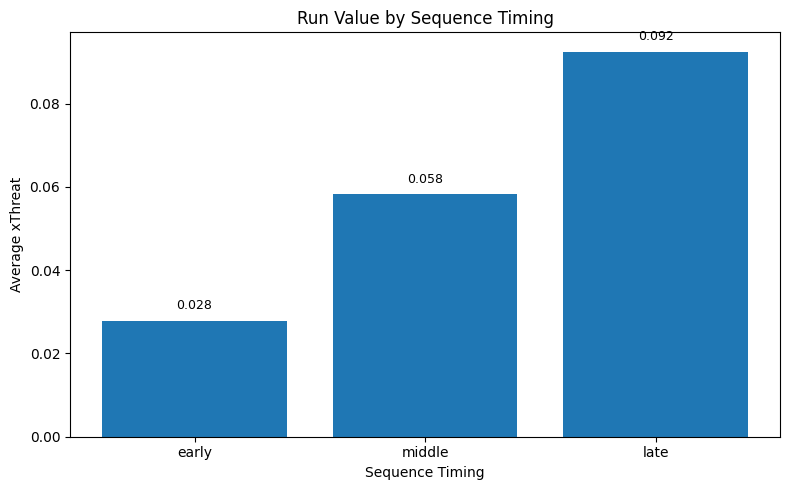

Shot rate by timing:

timing_bin
early     0.331
middle    0.417
late      0.429
Name: lead_to_shot, dtype: float64


In [38]:
import matplotlib.pyplot as plt

# Ensure correct order
order = ["early", "middle", "late"]
timing_xT = timing_xT.reindex(order)
timing_shot = timing_shot.reindex(order)

# Bar chart for xThreat
plt.figure(figsize=(8, 5))
bars = plt.bar(order, timing_xT)

plt.ylabel("Average xThreat")
plt.xlabel("Sequence Timing")
plt.title("Run Value by Sequence Timing")

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.002,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# Print shot rate separately
print("Shot rate by timing:\n")
print(timing_shot.round(3))

This chart shows a clear increase in run value as transitions develop, with late runs generating more than three times the xThreat of early runs.

Shot rate also increases across the sequence, from 0.331 in early phases to 0.429 in late phases, but less sharply than xThreat.

### Run Value by Timing

Run value increases as transitions develop:

- Early runs: 0.028 xThreat  
- Middle runs: 0.058 xThreat  
- Late runs: 0.092 xThreat  

Late runs generate more than three times the value of early runs.

Shot probability also increases from early (33%) to late (43%), although less sharply.

Late runs generate more than three times the value of early runs, while shot probability increases only marginally. This suggests that timing improves the quality of chances rather than just the likelihood of shooting.

---

### Interpretation

As transitions progress, actions take place closer to goal and in better conditions, increasing their impact.

From a football perspective, attacks build value over time: early runs create depth, middle runs support progression, and late runs occur in the most dangerous moments when the defence is more exposed.

### 2.3 Run Type Value by Timing

This section examines how the value of different run types changes depending on when they occur within a transition.

By combining run type and sequence timing, we can understand which movements are most effective at different stages of the attack.

In [39]:
# Average xThreat by run type and timing
run_timing_xT = (
    df_sequences
    .groupby(["event_subtype", "timing_bin"], observed=True)["xthreat"]
    .mean()
    .unstack()
)

# Count per run type and timing
run_timing_count = (
    df_sequences
    .groupby(["event_subtype", "timing_bin"], observed=True)
    .size()
    .unstack(fill_value=0)
)

print("Average xThreat by run type and timing:\n")
print(run_timing_xT)

print("\nRun counts by type and timing:\n")
print(run_timing_count)

Average xThreat by run type and timing:

timing_bin                early    middle      late
event_subtype                                      
behind                 0.060960  0.086667  0.070080
coming_short           0.001450       NaN       NaN
cross_receiver         0.093010  0.105218  0.163642
overlap                0.018350  0.033950  0.024825
pulling_half_space     0.015800       NaN       NaN
pulling_wide                NaN  0.001900       NaN
run_ahead_of_the_ball  0.020405  0.034391  0.049433
support                0.015674  0.020085  0.043657
underlap               0.013400  0.027000  0.025900

Run counts by type and timing:

timing_bin             early  middle  late
event_subtype                             
behind                    10      12     5
coming_short               2       0     0
cross_receiver            10      28    33
overlap                    6       2     4
pulling_half_space         1       0     0
pulling_wide               0       1     0
run_ahead_

#### Visual — Run Type Value by Timing

The heatmap below visualises how the value of each run type changes across the sequence.

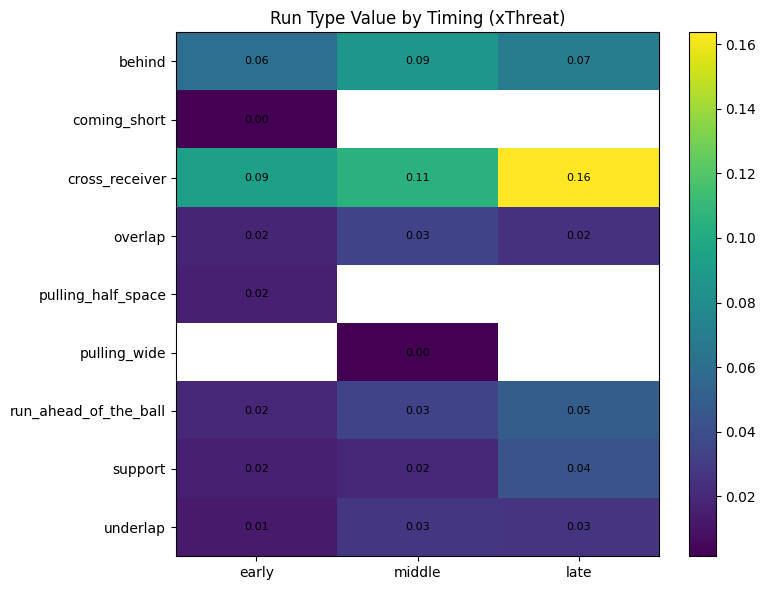

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Reorder timing columns
order = ["early", "middle", "late"]
run_timing_xT = run_timing_xT[order]

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Heatmap
cax = ax.imshow(run_timing_xT.values, aspect='auto')

# Axis labels
ax.set_xticks(np.arange(len(order)))
ax.set_xticklabels(order)
ax.set_yticks(np.arange(len(run_timing_xT.index)))
ax.set_yticklabels(run_timing_xT.index)

# Title
ax.set_title("Run Type Value by Timing (xThreat)")

# Add colorbar
fig.colorbar(cax)

# Annotate values inside cells
for i in range(run_timing_xT.shape[0]):
    for j in range(run_timing_xT.shape[1]):
        value = run_timing_xT.iloc[i, j]
        if not np.isnan(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

This heatmap clearly shows the dominance of cross-receiver runs in the late phase, where they reach the highest attacking value in the dataset.

### Run Type by Timing

Run value varies significantly depending on both movement type and timing within the transition.

Cross-receiver runs are consistently the most valuable, increasing from 0.093 xThreat early to 0.164 in late phases. They are also the most frequent in later stages, highlighting their role in final attacking actions.

Most run types show an increase in value as the sequence progresses. For example:
- Run ahead of the ball: 0.020 → 0.049  
- Support runs: 0.016 → 0.044  

This reinforces that the same movement can have different impact depending on when it occurs.

Behind runs show relatively high value in early and middle phases, suggesting their role in breaking defensive lines rather than finalising attacks.

---

### Interpretation

Different run types contribute differently across the transition.

- Early phase: forward and behind runs help create depth and disrupt defensive structure  
- Middle phase: a mix of movements supports progression  
- Late phase: cross-receiver runs dominate as the main source of attacking threat  

This highlights that run value is not only about the type of movement, but also its timing within the attacking sequence.

### 2.4 Sequence Composition

This section examines how different run types combine within the same transition sequences and how these combinations relate to attacking value.

Rather than analysing runs in isolation, the focus is on collective movement patterns, identifying which combinations of runs are associated with more dangerous attacking situations.

To ensure robustness, only combinations that appear multiple times in the dataset are considered.

In [41]:
# --- 1. Create run type combinations per sequence ---

sequence_composition = (
    df_sequences
    .groupby("sequence_id")["event_subtype"]
    .apply(lambda x: tuple(sorted(set(x))))
    .reset_index(name="run_combination")
)

# --- 2. Sequence-level xThreat (mean) ---

sequence_xT = (
    df_sequences
    .groupby("sequence_id")["xthreat"]
    .mean()
    .reset_index()
)

# --- 3. Merge ---

sequence_data = sequence_composition.merge(sequence_xT, on="sequence_id")

# --- 4. Aggregate by combination ---

combination_summary = (
    sequence_data
    .groupby("run_combination")
    .agg(
        avg_xT=("xthreat", "mean"),
        count=("sequence_id", "count")
    )
    .reset_index()
    .sort_values(by="avg_xT", ascending=False)
)

# --- 5. Filter (minimum frequency) ---

MIN_COUNT = 3

combination_filtered = combination_summary[
    combination_summary["count"] >= MIN_COUNT
]

print(combination_filtered)

                                      run_combination    avg_xT  count
20                          (cross_receiver, support)  0.073847      5
4   (behind, cross_receiver, run_ahead_of_the_ball...  0.072122      3
17            (cross_receiver, run_ahead_of_the_ball)  0.072057      3
6                   (behind, cross_receiver, support)  0.065089      3
18   (cross_receiver, run_ahead_of_the_ball, support)  0.064424     11
10                                  (behind, support)  0.059067      3
9            (behind, run_ahead_of_the_ball, support)  0.058959      7
24                   (run_ahead_of_the_ball, support)  0.042546      7
23                           (run_ahead_of_the_ball,)  0.025703      5


### Visual — Sequence Composition

The visual below highlights the strongest recurring run combinations, showing both attacking value and how often each pattern appears in the dataset.

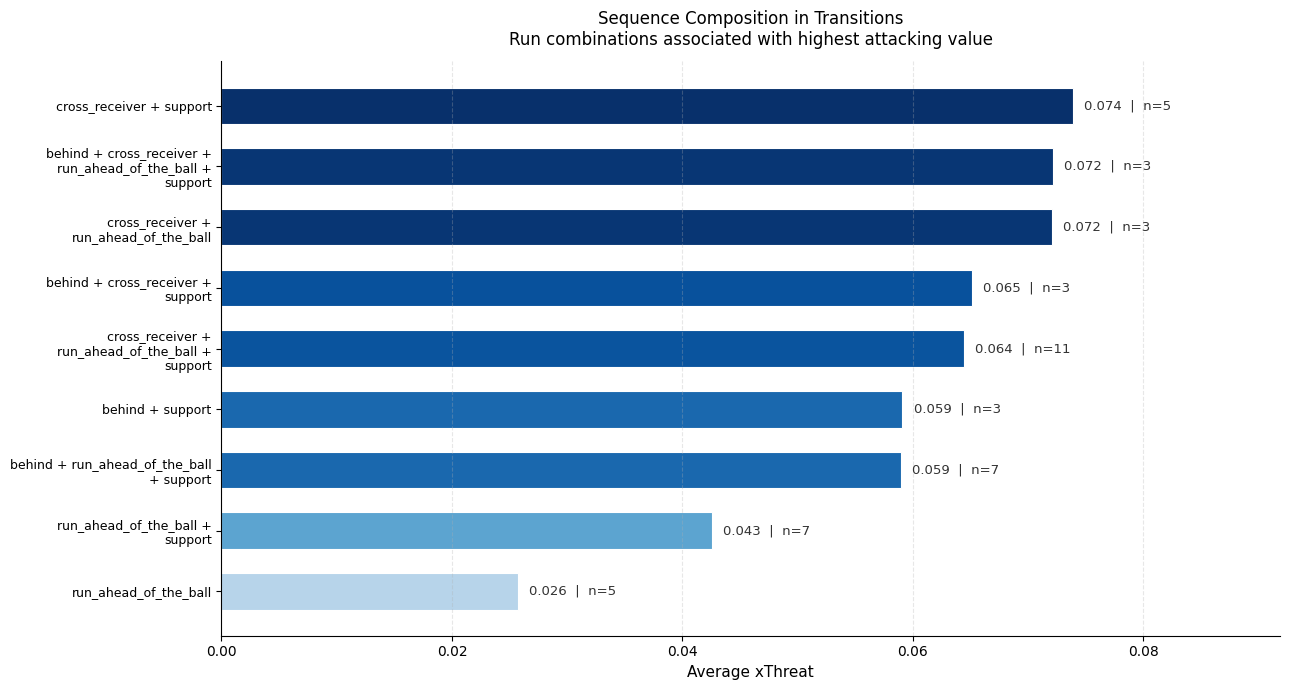

In [43]:
import matplotlib.pyplot as plt
import textwrap

# Prepare labels
plot_df = combination_filtered.copy()
plot_df["combination_label"] = plot_df["run_combination"].apply(
    lambda x: "\n".join(textwrap.wrap(" + ".join(x), 30))
)
plot_df = plot_df.sort_values("avg_xT", ascending=True)

# Colour bars by value — darker = higher value
import matplotlib.cm as cm
import numpy as np

norm = plt.Normalize(
    plot_df["avg_xT"].min(),
    plot_df["avg_xT"].max()
)
colours = cm.Blues(norm(plot_df["avg_xT"].values) * 0.7 + 0.3)

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    plot_df["combination_label"],
    plot_df["avg_xT"],
    color=colours,
    edgecolor="white",
    linewidth=0.8,
    height=0.6
)

# Value and count labels
for i, row in enumerate(plot_df.itertuples()):
    ax.text(
        row.avg_xT + 0.001,
        i,
        f"{row.avg_xT:.3f}  |  n={row.count}",
        va="center",
        fontsize=9.5,
        color="#333333"
    )

# Clean styling
ax.set_xlabel("Average xThreat", fontsize=11)
ax.set_ylabel("")
ax.set_title(
    "Sequence Composition in Transitions\nRun combinations associated with highest attacking value",
    fontsize=12,
    pad=12
)
ax.set_xlim(0, plot_df["avg_xT"].max() + 0.018)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=9)
ax.grid(axis="x", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

### Interpretation & Practical Application

Sequence composition captures which movements occur within the same transition, but not the order in which they happen. As a result, combinations should be interpreted as patterns within the attack rather than a strict sequence of actions.

The analysis shows that high-value transitions are consistently associated with combinations of movements rather than isolated runs.

Cross-receiver runs appear in all of the highest-value combinations, highlighting their central role in creating dangerous situations.

The most consistent high-value pattern observed is:

- Cross-receiver + run ahead of the ball + support

This combination appears 11 times and generates an average of 0.064 xThreat, making it the most reliable high-value structure in the dataset.

Comparing combinations to isolated runs reinforces the importance of interaction:

- Run ahead of the ball alone: ~0.026 xThreat
- Run ahead + support: ~0.043 xThreat
- Combinations including cross-receiver: ~0.064–0.074 xThreat

This represents more than a 2–3x increase in attacking value.

---

### High Frequency vs High Value

Not all commonly used transition patterns generate high attacking value.

In this dataset:

- Run ahead of the ball alone appears frequently but generates low value (~0.026 xThreat)
- Run ahead combined with support improves slightly (~0.043 xThreat)

In contrast:

- Sequences including cross-receiver runs generate ~0.064–0.074 xThreat

This highlights a key finding: teams often rely on simple forward runs, but the most dangerous transitions require coordinated movements — particularly the inclusion of cross-receiver runs.

From a football perspective, effective transitions follow a structured pattern:

- Early phase: forward runs create depth and exploit space after the regain
- Middle phase: support movements maintain structure and allow progression
- Late phase: cross-receiver runs create the final attacking threat

This highlights that value is created through coordinated movements across the sequence, not by individual actions in isolation.

---

### Coaching Implication

In this dataset, sequences that include cross-receiver runs generate significantly more threat than those relying only on forward runs.

A typical effective transition pattern is:

- Early: run ahead of the ball
- Middle: support around the ball
- Late: cross-receiver attacking run

This structure produces more than double the attacking value compared to simpler patterns without this coordination.

Rather than focusing on individual runs, teams should train transitions as connected movement patterns across phases of the attack.

## 3. Player Profiles

The previous sections identified how run value depends on context, timing, and movement combinations. This section brings those findings to life by looking at individual players.

Rather than ranking players by total output, the goal is to understand how different players create attacking value - whether through volume, timing, efficiency, or their role within high-value movement patterns.

Three players are selected to represent contrasting profiles. Each one tells a different story about how off-ball movement contributes to transitions.

### 3.1 - Selecting the Players

Before profiling individual players, all players with at least 5 transition runs are identified. This threshold ensures that profiles are based on a meaningful number of observations rather than isolated actions.

Three players are then selected based on contrasting characteristics:

- **G. May** — the highest volume of transition runs in the dataset
- **N. Botić** — the highest average xThreat per run
- **J. Randall** — a balanced profile combining volume with consistent involvement in attacking outcomes

The aim is not to identify the best player, but to show that value is created in fundamentally different ways.

In [44]:
# Build player summary table
player_summary = (
    df_sequences
    .groupby("player_name", observed=True)
    .agg(
        total_runs=("xthreat", "count"),
        avg_xthreat=("xthreat", "mean"),
        total_xthreat=("xthreat", "sum"),
        shot_rate=("lead_to_shot", "mean")
    )
    .reset_index()
    .sort_values("total_runs", ascending=False)
)

# Show only players with at least 5 transition runs
print("Players with 5+ transition runs:\n")
print(
    player_summary[player_summary["total_runs"] >= 5]
    .to_string(index=False)
)

Players with 5+ transition runs:

   player_name  total_runs  avg_xthreat  total_xthreat  shot_rate
        G. May          14     0.059986         0.8398   0.500000
    J. Randall          11     0.052745         0.5802   0.545455
    R. Danzaki          11     0.042473         0.4672   0.545455
   M. Francois          10     0.069170         0.6917   0.600000
      N. Botić          10     0.109160         1.0916   0.800000
     N. Moreno           9     0.078233         0.7041   0.444444
    L. Gillion           9     0.083622         0.7526   0.444444
       M. Ruhs           9     0.083644         0.7528   0.555556
   F. Gallegos           8     0.023875         0.1910   0.125000
     H. Ishige           8     0.078000         0.6240   0.375000
     N. Vergos           8     0.041962         0.3357   0.125000
 N. Velupillay           8     0.015413         0.1233   0.125000
   M. Grimaldi           8     0.104825         0.8386   0.375000
   L. Rogerson           8     0.108050   

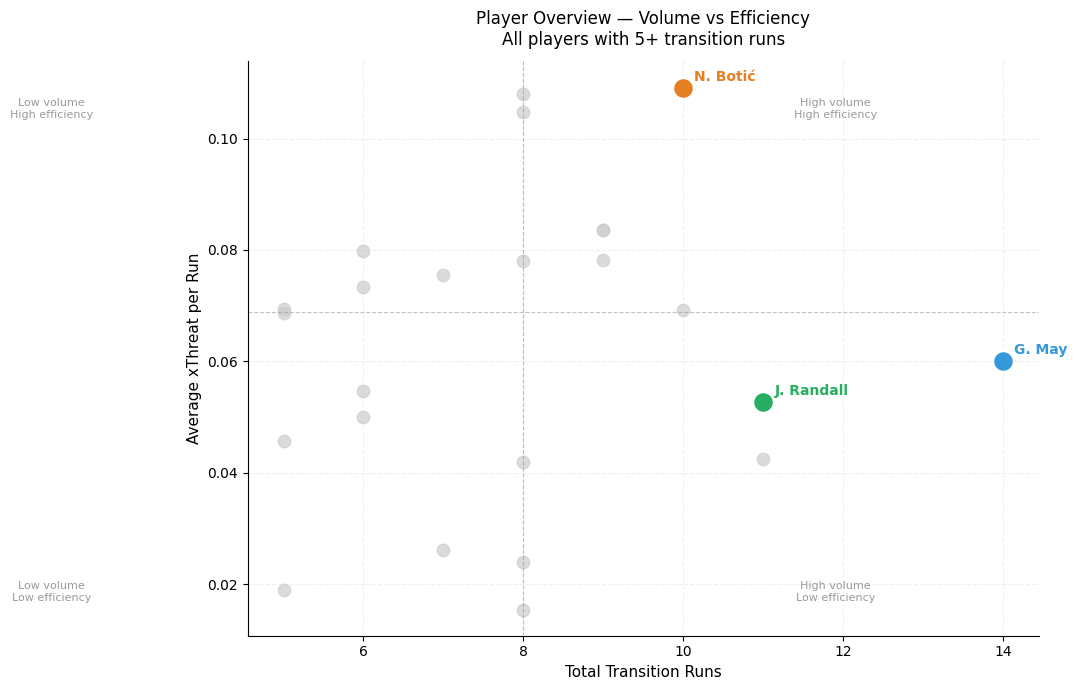

In [45]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Filter to players with 5+ runs for the visual
plot_summary = player_summary[
    player_summary["total_runs"] >= 5
].copy()

# Highlight the three selected players
highlight = ["G. May", "N. Botić", "J. Randall"]
highlight_colours = {
    "G. May": "#3498db",
    "N. Botić": "#e67e22",
    "J. Randall": "#27ae60"
}

fig, ax = plt.subplots(figsize=(11, 7))

# Plot all players in grey first
for _, row in plot_summary.iterrows():
    if row["player_name"] not in highlight:
        ax.scatter(
            row["total_runs"],
            row["avg_xthreat"],
            s=80,
            color="#cccccc",
            zorder=2,
            alpha=0.7
        )

# Plot the three selected players on top
for _, row in plot_summary.iterrows():
    if row["player_name"] in highlight:
        colour = highlight_colours[row["player_name"]]
        ax.scatter(
            row["total_runs"],
            row["avg_xthreat"],
            s=220,
            color=colour,
            zorder=4,
            edgecolors="white",
            linewidth=1.5
        )
        ax.annotate(
            row["player_name"],
            xy=(row["total_runs"], row["avg_xthreat"]),
            xytext=(8, 5),
            textcoords="offset points",
            fontsize=10,
            color=colour,
            fontweight="bold"
        )

# Reference lines at medians
median_runs = plot_summary["total_runs"].median()
median_xT = plot_summary["avg_xthreat"].median()

ax.axvline(
    median_runs,
    color="#999999",
    linestyle="--",
    linewidth=0.8,
    alpha=0.6
)
ax.axhline(
    median_xT,
    color="#999999",
    linestyle="--",
    linewidth=0.8,
    alpha=0.6
)

# Quadrant labels
ax.text(
    plot_summary["total_runs"].max() * 0.85,
    plot_summary["avg_xthreat"].max() * 0.95,
    "High volume\nHigh efficiency",
    fontsize=8,
    color="#999999",
    ha="center"
)
ax.text(
    plot_summary["total_runs"].max() * 0.15,
    plot_summary["avg_xthreat"].max() * 0.95,
    "Low volume\nHigh efficiency",
    fontsize=8,
    color="#999999",
    ha="center"
)
ax.text(
    plot_summary["total_runs"].max() * 0.85,
    plot_summary["avg_xthreat"].min() * 1.1,
    "High volume\nLow efficiency",
    fontsize=8,
    color="#999999",
    ha="center"
)
ax.text(
    plot_summary["total_runs"].max() * 0.15,
    plot_summary["avg_xthreat"].min() * 1.1,
    "Low volume\nLow efficiency",
    fontsize=8,
    color="#999999",
    ha="center"
)

ax.set_xlabel("Total Transition Runs", fontsize=11)
ax.set_ylabel("Average xThreat per Run", fontsize=11)
ax.set_title(
    "Player Overview — Volume vs Efficiency\nAll players with 5+ transition runs",
    fontsize=12,
    pad=12
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, alpha=0.2, linestyle="--")

plt.tight_layout()
plt.show()

The scatter plot shows all players with at least 5 transition runs,
with the three selected players highlighted.

Each dot represents one player. The x-axis shows how many transition
runs they made. The y-axis shows how much value each run generated
on average.

The dashed lines mark the median for each dimension, dividing the
chart into four quadrants.

N. Botić sits clearly in the high-efficiency zone - fewer runs but
significantly higher value per run. G. May sits at the opposite end -
the highest volume in the dataset with moderate efficiency. J. Randall
falls between them, combining reasonable volume with consistent
involvement in attacking outcomes.

Grey dots show all other players in the dataset. The three selected
players stand out immediately, which confirms they represent genuinely
contrasting profiles rather than arbitrary choices.

### 3.2  Where Do Players Run?

Before looking at the numbers, it helps to see where each player's transition runs actually happen on the pitch.

The maps below show each player's runs as directional arrows, coloured by run type. This gives an immediate picture of how they use space - whether they attack central areas, wide channels, or look to get in behind the defence.

In [46]:
!pip install mplsoccer -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 220.7 kB/s eta 0:00:00


In [47]:
from mplsoccer import VerticalPitch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Colour map by run type
run_colours = {
    "cross_receiver": "#e74c3c",
    "behind": "#e67e22",
    "support": "#3498db",
    "run_ahead_of_the_ball": "#2ecc71",
    "overlap": "#9b59b6",
    "underlap": "#1abc9c",
    "coming_short": "#95a5a6",
    "pulling_wide": "#f39c12",
    "pulling_half_space": "#d35400"
}

def plot_player_runs(player_name, df):
    player_runs = df[df["player_name"] == player_name].copy()

    # Convert SkillCorner centre-origin to mplsoccer bottom-left origin
    player_runs["plot_x_start"] = player_runs["x_start"] + 52.5
    player_runs["plot_y_start"] = player_runs["y_start"] + 34
    player_runs["plot_x_end"] = player_runs["x_end"] + 52.5
    player_runs["plot_y_end"] = player_runs["y_end"] + 34

    pitch = VerticalPitch(
        pitch_type="custom",
        pitch_length=105,
        pitch_width=68,
        half=False,
        pitch_color="white",
        line_color="#333333",
        linewidth=1.5
    )

    fig, ax = pitch.draw(figsize=(8, 8))

    for _, run in player_runs.iterrows():
        colour = run_colours.get(run["event_subtype"], "grey")
        pitch.arrows(
            run["plot_x_start"],
            run["plot_y_start"],
            run["plot_x_end"],
            run["plot_y_end"],
            ax=ax,
            color=colour,
            width=2,
            headwidth=4,
            headlength=3,
            alpha=0.8
        )

    total_runs = len(player_runs)
    avg_xT = player_runs["xthreat"].mean()

    ax.set_title(
        f"{player_name} — Transition Runs\n"
        f"{total_runs} runs | Avg xThreat: {avg_xT:.3f}",
        fontsize=12,
        pad=12
    )

    # Legend — only show run types this player actually made
    handles = [
        mpatches.Patch(
            color=colour,
            label=run_type.replace("_", " ").title()
        )
        for run_type, colour in run_colours.items()
        if run_type in player_runs["event_subtype"].values
    ]
    ax.legend(
        handles=handles,
        loc="upper left",
        fontsize=8,
        framealpha=0.8
    )

    plt.tight_layout()
    plt.show()

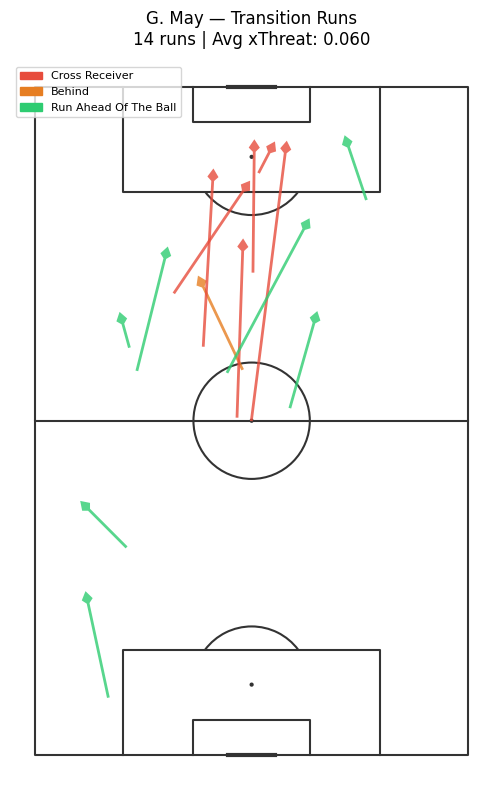

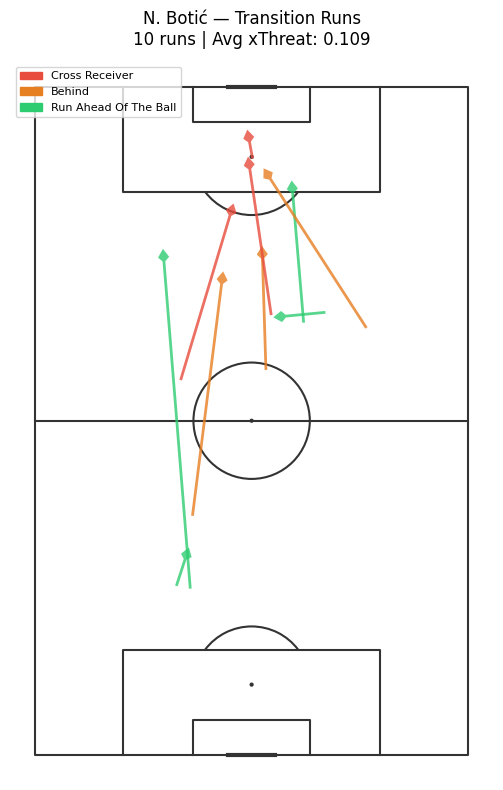

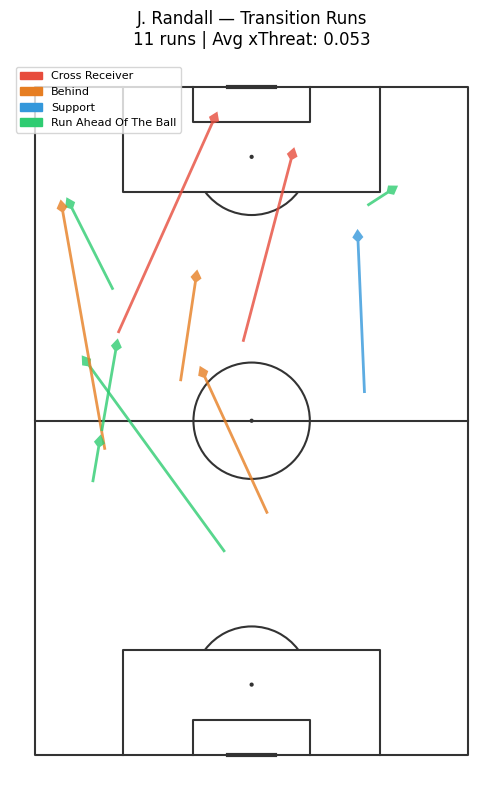

In [48]:
# Plot pitch maps for all three players
for player in ["G. May", "N. Botić", "J. Randall"]:
    plot_player_runs(player, df_sequences)

### Interpretation - G. May (Pitch Map)

The pitch map shows a high volume of runs distributed across the attacking half, with a clear mix of movement types.

Most runs start in deeper or midfield areas and progress forward, with a strong presence of **run ahead of the ball movements**. This reflects his role in driving the transition and providing forward options early in the attack.

Cross-receiver runs (red) appear closer to the penalty area, showing that he also contributes in more advanced positions as the attack develops. However, these are less dominant compared to his forward progression runs.

What stands out is the **variety and spread of his movement**, covering both wide and central channels.

---

### Football Interpretation

G. May operates as a **high-involvement transition player**, contributing across multiple phases of the attack.

He:
- initiates transitions through forward runs from deeper areas  
- supports progression by constantly offering movement options  
- occasionally arrives in dangerous areas to contribute to final actions  

This spatial pattern explains his profile: **high volume with consistent, but not elite, efficiency**. His value comes from creating options throughout the transition , not every run needs to be the decisive one.

### Interpretation - N. Botić (Pitch Map)

The pitch map shows that most of Botić’s runs start around the middle third and attack directly into the final third.

Cross-receiver runs (red) are concentrated in central and half-space areas near the box, while behind runs (orange) target space directly behind the defensive line — both high-value zones.

Run ahead of the ball movements (green) originate deeper, including one from his own half, showing occasional involvement in earlier transition phases.

Almost all runs finish in central attacking areas, with very little width in his movement.

---

### Football Interpretation

Botić consistently attacks the most dangerous spaces on the pitch.

He:
- focuses on central zones between and behind defenders  
- makes direct runs towards goal  
- appears in positions that maximise scoring probability  

This spatial pattern aligns with his high xThreat per run: **he operates where actions are most likely to become chances**.

He is a clear **transition finisher**, prioritising quality and positioning over volume.

### Interpretation - J. Randall (Pitch Map)

The pitch map shows a wide distribution of runs across both central and wide areas, with a mix of movement types.

A large number of runs are **run ahead of the ball**, often starting from deeper positions and progressing forward, indicating involvement in the early stages of transitions.

Behind runs (orange) and cross-receiver runs (red) are present but less frequent and less concentrated in central high-danger zones compared to Botić.

Support movements (blue) also appear, highlighting his role in connecting play rather than purely attacking space.

---

### Football Interpretation

Randall operates as a **transition connector**, contributing to the structure and progression of the attack.

He:
- supports the ball carrier in early phases  
- provides forward movement to maintain attacking momentum  
- occasionally attacks space but does not specialise in final actions  

His spatial profile reflects a player who **links phases of play rather than finishing them**.Players like Randall 's contribution is less visible in the final numbers , but without the structure they provide, the finisher has fewer opportunities to exploit.

### 3.3 G. May

G. May is the highest-volume transition runner in this dataset. His profile is built on consistent movement — offering options throughout the attack rather than specialising in a single phase or run type.

The code below analyses G. May's transition runs across two dimensions — which types of runs he makes and when in the sequence they occur. Shot involvement rate is also calculated to understand how often his movements connect to genuine attacking outcomes.

In [49]:
player = "G. May"
player_runs = df_sequences[df_sequences["player_name"] == player]

# Run type profile
run_type_profile_may = (
    player_runs
    .groupby("event_subtype", observed=True)["xthreat"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
    .rename(columns={"mean": "avg_xThreat", "count": "runs"})
)

# Timing profile
timing_profile_may = (
    player_runs
    .groupby("timing_bin", observed=True)["xthreat"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "avg_xThreat", "count": "runs"})
)

# Shot rate
shot_rate_may = player_runs["lead_to_shot"].mean()

print(f"=== {player} ===\n")
print("Run Type Profile:")
print(run_type_profile_may)
print("\nTiming Profile:")
print(timing_profile_may)
print(f"\nShot involvement rate: {shot_rate_may:.1%}")

=== G. May ===

Run Type Profile:
                       avg_xThreat  runs
event_subtype                           
cross_receiver              0.1073     6
behind                      0.0406     1
run_ahead_of_the_ball       0.0222     7

Timing Profile:
            avg_xThreat  runs
timing_bin                   
early          0.024900     4
middle         0.071667     6
late           0.077550     4

Shot involvement rate: 50.0%


The visual below shows G. May's profile across two panels. The left panel compares the average xThreat generated by each run type. The right panel shows how his run value changes across the early, middle, and late phases of the transition.

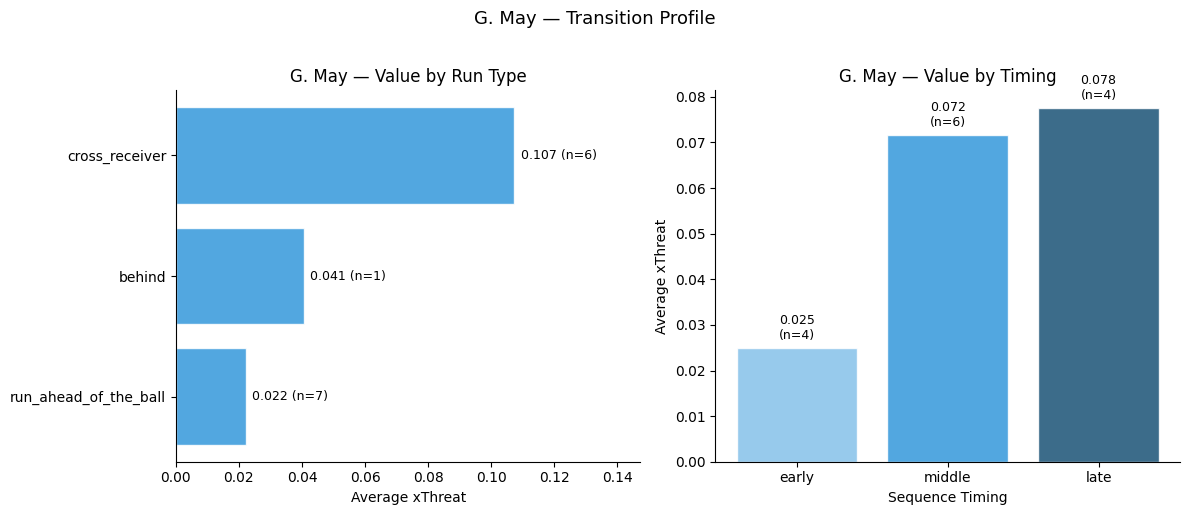

In [50]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left panel — run type
run_sorted = run_type_profile_may.sort_values("avg_xThreat", ascending=True)
axes[0].barh(
    run_sorted.index,
    run_sorted["avg_xThreat"],
    color="#3498db",
    alpha=0.85,
    edgecolor="white"
)
for i, (val, count) in enumerate(zip(
    run_sorted["avg_xThreat"],
    run_sorted["runs"]
)):
    axes[0].text(
        val + 0.002, i,
        f"{val:.3f} (n={int(count)})",
        va="center", fontsize=9
    )
axes[0].set_xlabel("Average xThreat")
axes[0].set_title("G. May — Value by Run Type")
axes[0].set_xlim(0, run_sorted["avg_xThreat"].max() + 0.04)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Right panel — timing
timing_order = ["early", "middle", "late"]
timing_vals = timing_profile_may.reindex(timing_order)["avg_xThreat"]
timing_counts = timing_profile_may.reindex(timing_order)["runs"]
axes[1].bar(
    timing_order,
    timing_vals,
    color=["#85c1e9", "#3498db", "#1a5276"],
    alpha=0.85,
    edgecolor="white"
)
for i, (val, count) in enumerate(zip(timing_vals, timing_counts)):
    if not np.isnan(val):
        axes[1].text(
            i, val + 0.002,
            f"{val:.3f}\n(n={int(count)})",
            ha="center", fontsize=9
        )
axes[1].set_xlabel("Sequence Timing")
axes[1].set_ylabel("Average xThreat")
axes[1].set_title("G. May — Value by Timing")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.suptitle("G. May — Transition Profile", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The next step looks at which transition sequences G. May appears in and whether those sequences belong to high-value or low-value movement combinations. This connects his individual profile back to the collective patterns identified in the sequence composition analysis.

In [52]:
# G. May — sequence combination involvement
may_sequences = df_sequences[
    df_sequences["player_name"] == "G. May"
]["sequence_id"].unique()

may_combos = (
    sequence_data[
        sequence_data["sequence_id"].isin(may_sequences)
    ]
    .groupby("run_combination")
    .agg(
        count=("sequence_id", "count"),
        avg_xT=("xthreat", "mean")
    )
    .sort_values("avg_xT", ascending=False)
    .reset_index()
)
may_combos["run_combination"] = may_combos["run_combination"].apply(
    lambda x: " + ".join(x)
)

print("G. May — Sequence Combination Involvement:\n")
print(may_combos.to_string(index=False))

G. May — Sequence Combination Involvement:

                                                     run_combination  count   avg_xT
                    cross_receiver + overlap + run_ahead_of_the_ball      1 0.156125
                    cross_receiver + run_ahead_of_the_ball + support      5 0.082312
                                     run_ahead_of_the_ball + support      1 0.065225
 behind + cross_receiver + overlap + run_ahead_of_the_ball + support      1 0.040529
                                   behind + cross_receiver + support      1 0.040400
behind + cross_receiver + run_ahead_of_the_ball + support + underlap      1 0.039457
                              cross_receiver + run_ahead_of_the_ball      1 0.035267
                                     behind + coming_short + support      1 0.019400
                                               run_ahead_of_the_ball      2 0.014590


G. May contributes throughout the transition rather than specialising
in one moment. His most valuable movement is the cross-receiver run,
but run ahead of the ball is what he does most - constantly offering
a forward option from the moment possession is won.

His value grows as the attack develops. Early runs create depth and
options, but his most dangerous contributions come in the middle and
late phases when space opens up and his cross-receiver runs become
genuinely threatening.

What stands out in his combination involvement is how often he appears
in the cross-receiver + run ahead + support pattern - the most reliable
high-value structure in the dataset. He shows up in it 5 times, which
tells you he is not just making volume runs - he is regularly part of
the movements that actually create danger.

**Profile: High-volume hybrid contributor.** He builds attacks through
consistent movement and keeps showing up in the right combinations when
it matters.

### 3.4 N. Botić

N. Botić is the most efficient transition runner in this dataset. He makes fewer runs than others, but each one carries significantly higher attacking value. His profile is defined by timing and selectivity rather than volume.

The code below analyses N. Botić's transition runs across the same
dimensions as the previous player - run type profile, timing preference,
and shot involvement rate.

In [53]:
player = "N. Botić"
player_runs = df_sequences[df_sequences["player_name"] == player]

# Run type profile
run_type_profile_botic = (
    player_runs
    .groupby("event_subtype", observed=True)["xthreat"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
    .rename(columns={"mean": "avg_xThreat", "count": "runs"})
)

# Timing profile
timing_profile_botic = (
    player_runs
    .groupby("timing_bin", observed=True)["xthreat"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "avg_xThreat", "count": "runs"})
)

# Shot rate
shot_rate_botic = player_runs["lead_to_shot"].mean()

print(f"=== {player} ===\n")
print("Run Type Profile:")
print(run_type_profile_botic)
print("\nTiming Profile:")
print(timing_profile_botic)
print(f"\nShot involvement rate: {shot_rate_botic:.1%}")

=== N. Botić ===

Run Type Profile:
                       avg_xThreat  runs
event_subtype                           
behind                    0.212300     3
cross_receiver            0.102667     3
run_ahead_of_the_ball     0.036675     4

Timing Profile:
            avg_xThreat  runs
timing_bin                   
early          0.066100     3
middle         0.157300     4
late           0.088033     3

Shot involvement rate: 80.0%


The visual below shows N. Botić's profile across run type and timing,
using the same format as G. May for easy comparison.

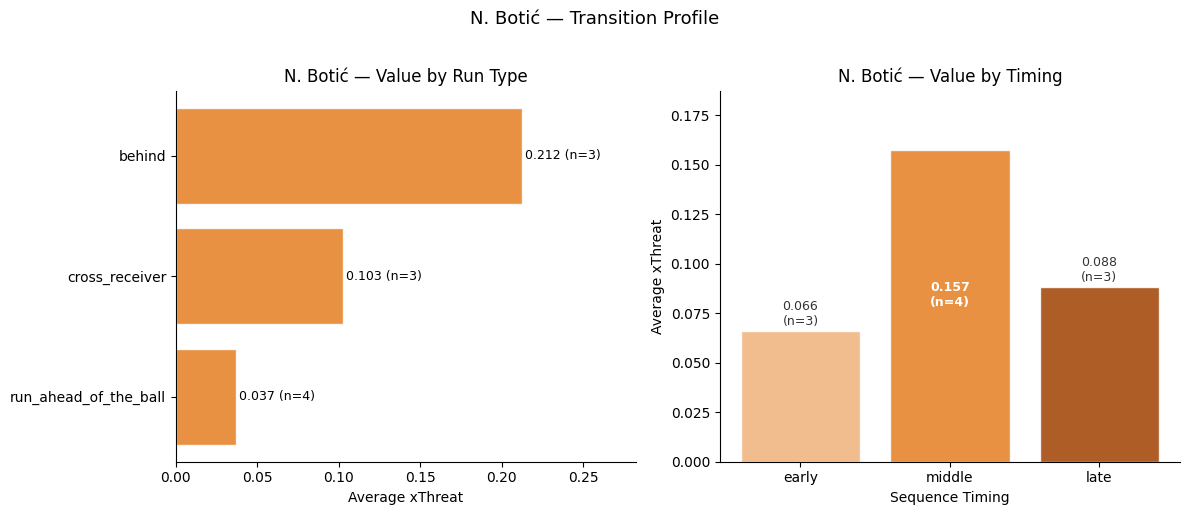

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left panel — run type
run_sorted = run_type_profile_botic.sort_values("avg_xThreat", ascending=True)
axes[0].barh(
    run_sorted.index,
    run_sorted["avg_xThreat"],
    color="#e67e22",
    alpha=0.85,
    edgecolor="white"
)
for i, (val, count) in enumerate(zip(
    run_sorted["avg_xThreat"],
    run_sorted["runs"]
)):
    axes[0].text(
        val + 0.002, i,
        f"{val:.3f} (n={int(count)})",
        va="center", fontsize=9
    )
axes[0].set_xlabel("Average xThreat")
axes[0].set_title("N. Botić — Value by Run Type")
axes[0].set_xlim(0, run_sorted["avg_xThreat"].max() + 0.07)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Right panel — timing
timing_order = ["early", "middle", "late"]
timing_vals = timing_profile_botic.reindex(timing_order)["avg_xThreat"]
timing_counts = timing_profile_botic.reindex(timing_order)["runs"]

axes[1].bar(
    timing_order,
    timing_vals,
    color=["#f0b27a", "#e67e22", "#a04000"],
    alpha=0.85,
    edgecolor="white"
)

# Fixed label positioning — place inside bar if value is high
for i, (val, count) in enumerate(zip(timing_vals, timing_counts)):
    if not np.isnan(val):
        # If bar is tall enough place label inside, otherwise above
        if val > timing_vals.max() * 0.6:
            axes[1].text(
                i, val * 0.5,
                f"{val:.3f}\n(n={int(count)})",
                ha="center", fontsize=9,
                color="white",
                fontweight="bold"
            )
        else:
            axes[1].text(
                i, val + 0.003,
                f"{val:.3f}\n(n={int(count)})",
                ha="center", fontsize=9,
                color="#333333"
            )

axes[1].set_xlabel("Sequence Timing")
axes[1].set_ylabel("Average xThreat")
axes[1].set_title("N. Botić — Value by Timing")
axes[1].set_ylim(0, timing_vals.max() + 0.03)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.suptitle("N. Botić — Transition Profile", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The next step checks which transition sequences N. Botić appears in
and whether they belong to high-value movement combinations.

In [56]:
# N. Botić — sequence combination involvement
botic_sequences = df_sequences[
    df_sequences["player_name"] == "N. Botić"
]["sequence_id"].unique()

botic_combos = (
    sequence_data[
        sequence_data["sequence_id"].isin(botic_sequences)
    ]
    .groupby("run_combination")
    .agg(
        count=("sequence_id", "count"),
        avg_xT=("xthreat", "mean")
    )
    .sort_values("avg_xT", ascending=False)
    .reset_index()
)
botic_combos["run_combination"] = botic_combos["run_combination"].apply(
    lambda x: " + ".join(x)
)

print("N. Botić — Sequence Combination Involvement:\n")
print(botic_combos.to_string(index=False))

N. Botić — Sequence Combination Involvement:

                                                      run_combination  count   avg_xT
                             behind + run_ahead_of_the_ball + support      2 0.083605
            behind + cross_receiver + run_ahead_of_the_ball + support      1 0.083127
                                                     behind + support      1 0.078467
                                             cross_receiver + overlap      1 0.059275
cross_receiver + pulling_half_space + run_ahead_of_the_ball + support      1 0.047733
                     cross_receiver + run_ahead_of_the_ball + support      1 0.045380
                      behind + cross_receiver + run_ahead_of_the_ball      1 0.033475


Botić does not need many runs - he just needs the right ones.

Behind runs are his most dangerous movement at 0.212 xThreat, attacking
space directly behind the defensive line. Cross-receiver runs add a
second threat at 0.103, showing he can also exploit central spaces as
the attack develops.

His timing peaks sharply in the middle phase at 0.157 - more than double
his early and late values. He identifies the decisive moment as the
transition develops and attacks it precisely.

With an 80% shot involvement rate, eight out of ten of his runs connect
directly to a shot situation. That is precision, not volume.

His combination involvement confirms this - he most frequently appears
in behind-led patterns, built around attacking space rather than
receiving in front of defenders.

**Profile: Pure transition finisher.** When the transition reaches its
most dangerous moment, Botić is already there.

### 3.5 J. Randall

J. Randall sits between G. May and N. Botić in terms of both volume
and efficiency. His profile is defined by consistent involvement across
different phases and run types, making him a connector within the
transition structure.

The code below analyses J. Randall's transition runs across the same
dimensions — run type profile, timing preference, and shot involvement rate.

In [57]:
player = "J. Randall"
player_runs = df_sequences[df_sequences["player_name"] == player]

# Run type profile
run_type_profile_randall = (
    player_runs
    .groupby("event_subtype", observed=True)["xthreat"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
    .rename(columns={"mean": "avg_xThreat", "count": "runs"})
)

# Timing profile
timing_profile_randall = (
    player_runs
    .groupby("timing_bin", observed=True)["xthreat"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "avg_xThreat", "count": "runs"})
)

# Shot rate
shot_rate_randall = player_runs["lead_to_shot"].mean()

print(f"=== {player} ===\n")
print("Run Type Profile:")
print(run_type_profile_randall)
print("\nTiming Profile:")
print(timing_profile_randall)
print(f"\nShot involvement rate: \
{shot_rate_randall:.1%}")

=== J. Randall ===

Run Type Profile:
                       avg_xThreat  runs
event_subtype                           
cross_receiver            0.195650     2
support                   0.046600     1
behind                    0.030233     3
run_ahead_of_the_ball     0.010320     5

Timing Profile:
            avg_xThreat  runs
timing_bin                   
early          0.037067     6
middle         0.071560     5

Shot involvement rate: 54.5%


The visual below shows J. Randall's profile across run type and timing,
using the same format as the previous players for easy comparison.

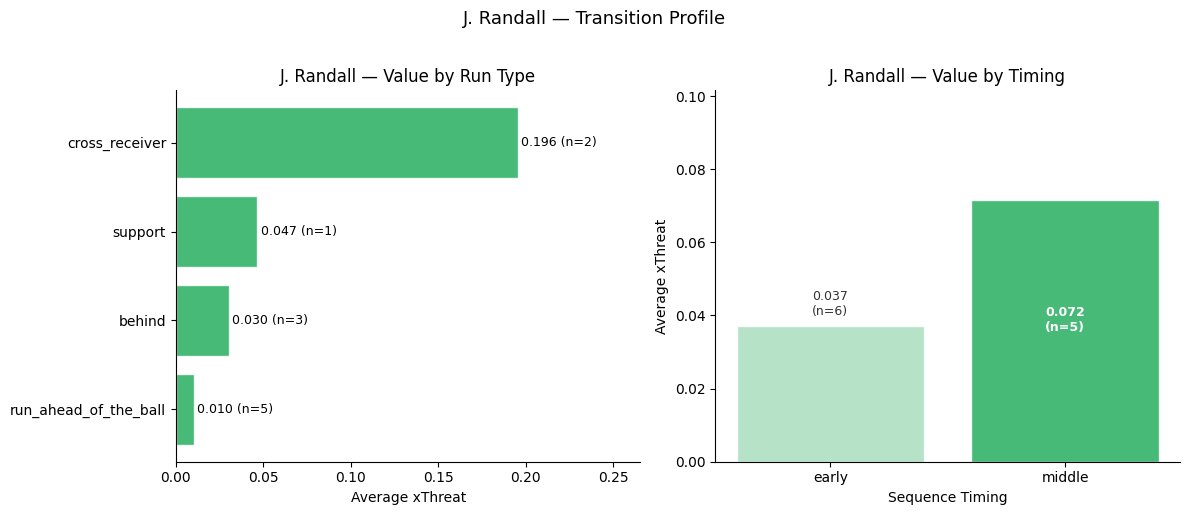

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left panel — run type
run_sorted = run_type_profile_randall.sort_values(
    "avg_xThreat", ascending=True
)
axes[0].barh(
    run_sorted.index,
    run_sorted["avg_xThreat"],
    color="#27ae60",
    alpha=0.85,
    edgecolor="white"
)
for i, (val, count) in enumerate(zip(
    run_sorted["avg_xThreat"],
    run_sorted["runs"]
)):
    axes[0].text(
        val + 0.002, i,
        f"{val:.3f} (n={int(count)})",
        va="center", fontsize=9
    )
axes[0].set_xlabel("Average xThreat")
axes[0].set_title("J. Randall — Value by Run Type")
axes[0].set_xlim(0, run_sorted["avg_xThreat"].max() + 0.07)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Right panel — timing
timing_order = ["early", "middle", "late"]
timing_vals = timing_profile_randall.reindex(timing_order)["avg_xThreat"]
timing_counts = timing_profile_randall.reindex(timing_order)["runs"]

axes[1].bar(
    timing_order,
    timing_vals,
    color=["#a9dfbf", "#27ae60", "#1e8449"],
    alpha=0.85,
    edgecolor="white"
)

for i, (val, count) in enumerate(zip(timing_vals, timing_counts)):
    if not np.isnan(val):
        if val > timing_vals.max() * 0.6:
            axes[1].text(
                i, val * 0.5,
                f"{val:.3f}\n(n={int(count)})",
                ha="center", fontsize=9,
                color="white",
                fontweight="bold"
            )
        else:
            axes[1].text(
                i, val + 0.003,
                f"{val:.3f}\n(n={int(count)})",
                ha="center", fontsize=9,
                color="#333333"
            )

axes[1].set_xlabel("Sequence Timing")
axes[1].set_ylabel("Average xThreat")
axes[1].set_title("J. Randall — Value by Timing")
axes[1].set_ylim(0, timing_vals.max() + 0.03)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.suptitle("J. Randall — Transition Profile", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The next step checks which transition sequences J. Randall appears in
and whether they belong to high-value movement combinations.

In [60]:
# J. Randall — sequence combination involvement
randall_sequences = df_sequences[
    df_sequences["player_name"] == "J. Randall"
]["sequence_id"].unique()

randall_combos = (
    sequence_data[
        sequence_data["sequence_id"].isin(randall_sequences)
    ]
    .groupby("run_combination")
    .agg(
        count=("sequence_id", "count"),
        avg_xT=("xthreat", "mean")
    )
    .sort_values("avg_xT", ascending=False)
    .reset_index()
)
randall_combos["run_combination"] = randall_combos["run_combination"].apply(
    lambda x: " + ".join(x)
)

print("J. Randall — Sequence Combination Involvement:\n")
print(randall_combos.to_string(index=False))

J. Randall — Sequence Combination Involvement:

                                                     run_combination  count   avg_xT
                                   behind + cross_receiver + support      2 0.084833
                    cross_receiver + run_ahead_of_the_ball + support      4 0.078825
behind + cross_receiver + run_ahead_of_the_ball + support + underlap      1 0.039457


Randall is a consistent presence in transitions, contributing across
multiple phases without specialising in any single moment.

Cross-receiver runs are his most valuable movement at 0.196 xThreat,
but he only makes two of them. Run ahead of the ball is his most
frequent movement with 5 occurrences but generates the lowest value
at 0.010. This gap between his most frequent and most valuable movement
tells you something important — he contributes a lot of structural
runs that keep the attack moving, with occasional high-impact actions
when the opportunity arises.

His timing profile shows no late-phase presence at all. His
contributions are concentrated in the early and middle phases, with
value rising from 0.037 to 0.072 as the transition develops. He helps
build the attack rather than finish it.

His shot involvement rate of 54.5% sits between G. May and Botić —
consistent but not elite. His runs connect to outcomes regularly,
just not as directly as a pure finisher would.

His combination involvement shows he appears in high-value sequences —
behind + cross-receiver + support twice, and cross-receiver + run ahead
+ support four times. He is regularly part of the patterns that generate
the most danger, even if he is not the player making the decisive
final run.

**Profile: Transition connector.** Randall links phases, maintains
structure, and keeps showing up in the right combinations. Without
players like him, the finisher has fewer opportunities to exploit.

### 3.6 Comparing the Three Profiles

With individual profiles established, the three players can now be
compared directly across the key dimensions of transition movement.

The visual below plots all three players on a single chart, comparing
total transition runs against average xThreat per run. This separates
volume from efficiency and makes the contrasting profiles immediately visible.

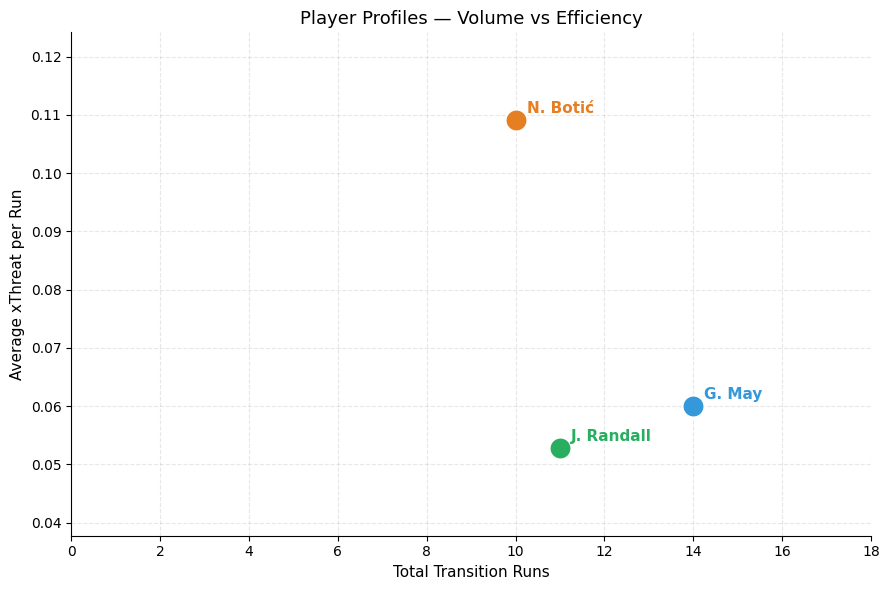

In [61]:
import matplotlib.pyplot as plt

player_plot = player_summary[
    player_summary["player_name"].isin(["G. May", "N. Botić", "J. Randall"])
].copy()

colours = {
    "G. May": "#3498db",
    "N. Botić": "#e67e22",
    "J. Randall": "#27ae60"
}

fig, ax = plt.subplots(figsize=(9, 6))

for _, row in player_plot.iterrows():
    ax.scatter(
        row["total_runs"],
        row["avg_xthreat"],
        s=250,
        color=colours.get(row["player_name"], "grey"),
        zorder=3,
        edgecolors="white",
        linewidth=1.5
    )
    ax.annotate(
        row["player_name"],
        xy=(row["total_runs"], row["avg_xthreat"]),
        xytext=(8, 5),
        textcoords="offset points",
        fontsize=11,
        color=colours.get(row["player_name"], "grey"),
        fontweight="bold"
    )

ax.set_xlabel("Total Transition Runs", fontsize=11)
ax.set_ylabel("Average xThreat per Run", fontsize=11)
ax.set_title("Player Profiles — Volume vs Efficiency", fontsize=13)
ax.set_xlim(0, player_plot["total_runs"].max() + 4)
ax.set_ylim(
    player_plot["avg_xthreat"].min() - 0.015,
    player_plot["avg_xthreat"].max() + 0.015
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

The scatter plot separates the three players clearly.

N. Botić sits at the top - fewer runs but significantly higher value
per run. G. May sits to the right - the highest volume with moderate
efficiency. J. Randall falls between them - moderate volume, moderate
efficiency - reflecting his connector role.

The next visual compares how each player's run value changes across
the early, middle, and late phases of the transition. This shows
not just how much value they create but when they create it.

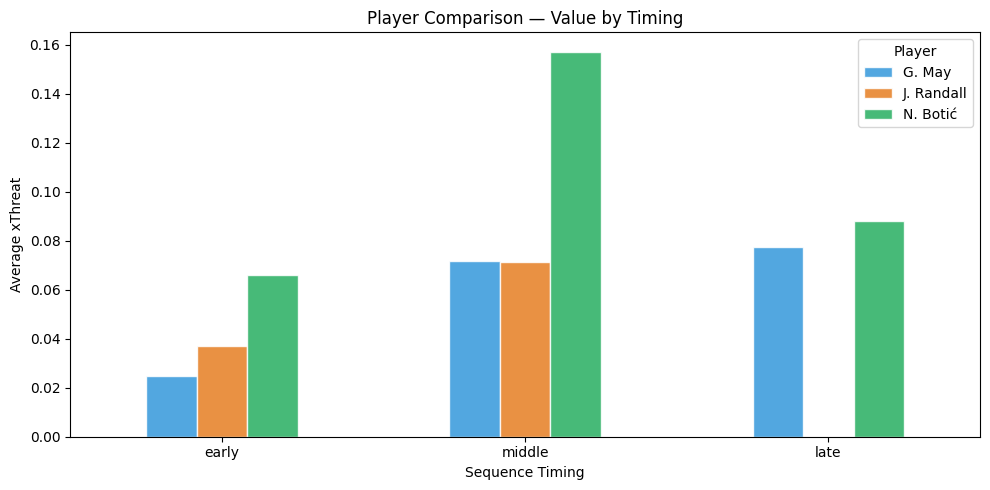

In [62]:
selected_players = ["G. May", "N. Botić", "J. Randall"]

timing_compare = (
    df_sequences[df_sequences["player_name"].isin(selected_players)]
    .groupby(["player_name", "timing_bin"], observed=True)["xthreat"]
    .mean()
    .unstack()
)[["early", "middle", "late"]]

timing_compare.T.plot(
    kind="bar",
    figsize=(10, 5),
    color=["#3498db", "#e67e22", "#27ae60"],
    alpha=0.85,
    edgecolor="white"
)
plt.xlabel("Sequence Timing")
plt.ylabel("Average xThreat")
plt.title("Player Comparison — Value by Timing")
plt.legend(title="Player")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.7 Transition Roles

Across the three profiles, three distinct roles emerge.

**Transition Finisher — N. Botić**
Creates value through timing and selectivity. High efficiency, lower
volume. Concentrates in decisive moments with behind and cross-receiver
runs. 80% shot involvement.

**High-Volume Contributor — G. May**
Creates value through consistent presence. Highest volume of runs.
Contributes across all phases, with cross-receiver runs generating
his highest threat in the late phase. 50% shot involvement.

**Transition Connector — J. Randall**
Creates value by linking phases. Balanced volume with consistent
involvement. Broad run type profile focused on the early and middle
phases. 54.55% shot involvement.

These roles matter for recruitment. Knowing whether a player is a
finisher, a facilitator, or a connector provides more useful
information than comparing raw run counts alone. Different teams
need different profiles depending on how they want to attack in
transition.

### Note

This analysis evaluates off-ball runs within transition sequences by
identifying which movements occur within the same attacking phase.

Players rarely make a single isolated run. In practice, a player might
make an early forward run to create depth, provide support in the middle
phase, and then attack space in the final phase — all within the same
transition.

The current analysis captures the presence and value of these movements
but does not model the exact order or interaction between individual
runs within a sequence. This represents a natural next step for future
work, where tracking the timing and spatial relationship between
simultaneous movements could provide deeper insight into how players
create space and influence attacking outcomes.

## 4. Physical Layer

The previous sections focused on context, timing, and movement combinations.
This section adds a physical dimension by asking a simple question:

Do faster runs generate more attacking threat in transitions?

SkillCorner tracking data includes run-level speed information, which allows
us to test whether physical intensity plays a role in run value — or whether
timing and context matter more than raw speed.

This is treated as an exploratory layer rather than a central finding. The
goal is to understand whether physical execution adds anything beyond what
context and timing already explain.

### 4.1 — Validating the Speed Data

Before using speed information in the analysis, the data needs to be
checked for completeness and reliability. This step confirms whether
the physical layer is suitable to use and avoids drawing conclusions
from incomplete or unreliable data.

In [66]:
# Check speed data completeness
print("Speed data availability:\n")
print(f"Total transition runs: {len(df_sequences)}")
print(f"Missing speed values: {df_sequences['speed_avg'].isnull().sum()}")
print(f"Missing (%): {df_sequences['speed_avg'].isnull().mean() * 100:.1f}%")

print("\nSpeed distribution:\n")
print(df_sequences["speed_avg"].describe().round(2))

print("\nSkillCorner speed band distribution:\n")
print(df_sequences["speed_avg_band"].value_counts())

Speed data availability:

Total transition runs: 304
Missing speed values: 1
Missing (%): 0.3%

Speed distribution:

count    303.00
mean      20.44
std        3.30
min       15.17
25%       17.76
50%       19.91
75%       22.82
max       30.27
Name: speed_avg, dtype: float64

SkillCorner speed band distribution:

speed_avg_band
running      155
hsr          116
sprinting     32
Name: count, dtype: int64


The speed data is available for 303 of 304 transition runs —
essentially complete with only one missing value.

What stands out immediately is that all transition runs in this
dataset occur at relatively high speeds, ranging from 15 to 30 km/h
with a mean of around 20 km/h. This is not surprising — transition
situations naturally demand fast, purposeful movement from attacking
players.

Rather than defining custom speed thresholds, this analysis uses
SkillCorner's own speed band classification, which categorises each
run into one of three intensity levels:

- **Running** — 155 runs (51%)
- **HSR** (High Speed Running) — 116 runs (38%)
- **Sprinting** — 32 runs (11%)

Using SkillCorner's own classification ensures the physical layer
is evaluated using the same framework they apply internally, making
the findings directly comparable to their own product metrics.

Only 11% of transition runs reach full sprint intensity — which
reflects the reality of off-ball movement in transitions. Most players
are running or moving at high speed rather than sprinting flat out.

### 4.2 — Run Value by Speed Band

The code below calculates the average xThreat generated within each
speed band. This tests whether physically more intense runs — those
made at higher speeds — tend to produce more attacking threat, or
whether the relationship is more nuanced.

In [67]:
# Use SkillCorner's own speed band classification
speed_df = df_sequences.dropna(subset=["speed_avg_band"]).copy()

# Calculate xThreat by speed band
speed_xT = (
    speed_df
    .groupby("speed_avg_band", observed=True)["xthreat"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "avg_xThreat", "count": "runs"})
)

# Reorder bands logically
band_order = ["running", "hsr", "sprinting"]
speed_xT = speed_xT.reindex(band_order)

print("Average xThreat by speed band:\n")
print(speed_xT)

Average xThreat by speed band:

                avg_xThreat  runs
speed_avg_band                   
running            0.043184   155
hsr                0.063780   116
sprinting          0.082138    32


The chart below shows average xThreat for each speed band. Each bar
represents one intensity level, with the exact value and number of
runs labelled directly on the chart.

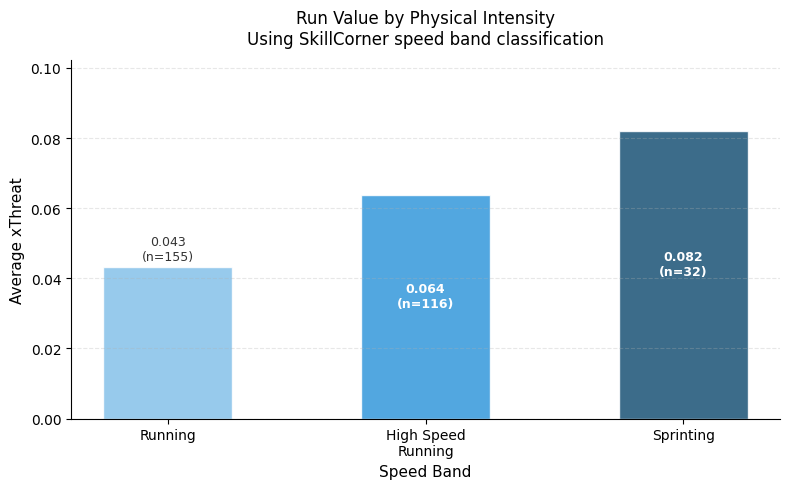

In [68]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))

colours = ["#85c1e9", "#3498db", "#1a5276"]
labels = ["Running", "High Speed\nRunning", "Sprinting"]

ax.bar(
    labels,
    speed_xT["avg_xThreat"],
    color=colours,
    alpha=0.85,
    edgecolor="white",
    width=0.5
)

for i, (val, count) in enumerate(zip(
    speed_xT["avg_xThreat"],
    speed_xT["runs"]
)):
    if not np.isnan(val):
        if val > speed_xT["avg_xThreat"].max() * 0.6:
            ax.text(
                i, val * 0.5,
                f"{val:.3f}\n(n={int(count)})",
                ha="center",
                fontsize=9,
                color="white",
                fontweight="bold"
            )
        else:
            ax.text(
                i, val + 0.002,
                f"{val:.3f}\n(n={int(count)})",
                ha="center",
                fontsize=9,
                color="#333333"
            )

ax.set_xlabel("Speed Band", fontsize=11)
ax.set_ylabel("Average xThreat", fontsize=11)
ax.set_title(
    "Run Value by Physical Intensity\n"
    "Using SkillCorner speed band classification",
    fontsize=12,
    pad=12
)
ax.set_ylim(0, speed_xT["avg_xThreat"].max() + 0.02)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

### 4.3 - Interpretation

The pattern is clear — the faster the run, the more dangerous it tends
to be.

Running produces 0.043 xThreat on average. High speed running jumps
to 0.064. Sprinting reaches 0.082 — almost double the value of a
standard running movement.

This makes sense from a football perspective. A player sprinting in
transition is usually doing one of two things — attacking space behind
the defensive line or making a direct run into a dangerous area. A
player running at lower intensity is more likely offering support,
staying connected to the ball carrier, or maintaining structure. Both
have value, but they create threat in very different ways.

That said, sprint runs are the smallest group in this dataset with
only 32 occurrences. The pattern is consistent but should be treated
as a signal rather than a definitive conclusion.

There is also something worth noting about what speed actually
represents here. The highest-value run types — cross-receiver and
behind runs — are naturally faster movements. So part of what we are
seeing may be the run type driving the speed rather than speed driving
the value.

The real picture is probably this: speed amplifies value when it
combines with the right movement, the right moment, and the right
context. A sprinting support run is not the same as a sprinting run
in behind — even if the speed is identical.

**The takeaway:** Faster runs generate more threat in transitions.
But speed on its own is not the answer — it works when everything
else is already in place.